In [1]:
# !pip install openmeteo-requests requests-cache retry-requests pandas numpy scikit-learn matplotlib seaborn
# !pip install xgboost tensorflow

# 1) Config: Location, date range, class mapping

In [3]:
import pandas as pd
import numpy as np
import openmeteo_requests
import requests_cache
from retry_requests import retry

# --- Location (Colombo) ---
LAT, LON = 6.9355, 79.8487
TZ = "auto"  # auto -> Asia/Colombo

# --- Training horizon ---
START_DATE = "2020-01-01"
END_DATE   = "2024-12-31"

# --- Rolling window size (hours) ---
WINDOW_H = 24

# --- Prediction horizon (changed to 24 hours for next-day rainfall) ---
PREDICT_H = 24  # Predict total rainfall over next 24 hours


# 2) Fetch hourly data from Open-Meteo

In [4]:
# Cached + retried session
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.25)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "hourly": ["temperature_2m", "precipitation"],
    "timezone": TZ
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]

hourly = response.Hourly()
time_index = pd.date_range(
    start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
    end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=hourly.Interval()),
    inclusive="left"
)

df_hourly = pd.DataFrame({
    "time_utc": time_index,
    "temperature_2m": hourly.Variables(0).ValuesAsNumpy(),
    "precipitation": hourly.Variables(1).ValuesAsNumpy()
})

# Convert to Asia/Colombo
df_hourly["time"] = df_hourly["time_utc"].dt.tz_convert("Asia/Colombo")
df_hourly = df_hourly.drop(columns=["time_utc"]).sort_values("time").reset_index(drop=True)

print(f"Data loaded: {len(df_hourly)} hourly records from {df_hourly['time'].min()} to {df_hourly['time'].max()}")


Data loaded: 43848 hourly records from 2020-01-01 00:00:00+05:30 to 2024-12-31 23:00:00+05:30


In [5]:
df_hourly

,temperature_2m,precipitation,time
0,25.206501,0.1,2020-01-01 00:00:00+05:30
1,24.906500,0.0,2020-01-01 01:00:00+05:30
2,24.706501,0.1,2020-01-01 02:00:00+05:30
3,24.556499,0.1,2020-01-01 03:00:00+05:30
4,24.306499,0.0,2020-01-01 04:00:00+05:30
...,...,...,...
43843,25.506500,0.0,2024-12-31 19:00:00+05:30
43844,25.306499,0.0,2024-12-31 20:00:00+05:30
43845,24.956501,0.0,2024-12-31 21:00:00+05:30
43846,24.606501,0.0,2024-12-31 22:00:00+05:30


# 3) Build rolling 24-hour datasets

## For Traditional ML Models

In [6]:
def build_aggregated_dataset(df: pd.DataFrame, window_h: int = 24, predict_h: int = 24):
    """
    Returns a DataFrame with features aggregated over the previous `window_h` hours,
    and target = total rainfall (mm) over the next `predict_h` hours.
    
    This is for REGRESSION, not classification.
    
    Args:
      window_h: Input window size (24 hours = past day)
      predict_h: Prediction horizon (24 hours = next day)
    """
    recs = []
    df = df.sort_values("time").reset_index(drop=True)

    for i in range(window_h, len(df) - predict_h):
        past = df.iloc[i - window_h:i]           # past 24 hours
        now = df.iloc[i - 1]                     # last hour of input window
        future = df.iloc[i:i + predict_h]        # next 24 hours

        # Aggregated features from past 24 hours
        rec = {
            "time": now["time"],  # reference time = end of input window
            "temp_mean_24h": past["temperature_2m"].mean(),
            "temp_max_24h": past["temperature_2m"].max(),
            "temp_min_24h": past["temperature_2m"].min(),
            "temp_std_24h": past["temperature_2m"].std(),
            "rain_sum_24h": past["precipitation"].sum(),
            "rain_max_24h": past["precipitation"].max(),
            "rain_hours_24h": int((past["precipitation"] > 0).sum()),
            "last_temp": now["temperature_2m"],
            "last_rain": now["precipitation"],
        }

        # Target: total rainfall (mm) over next 24 hours (REGRESSION)
        total_future_rain = future["precipitation"].sum()
        rec["y_rainfall_next_24h"] = float(total_future_rain)

        recs.append(rec)

    return pd.DataFrame(recs)

# Build aggregated dataset
df_agg = build_aggregated_dataset(df_hourly, window_h=WINDOW_H, predict_h=PREDICT_H)

print(f"Aggregated dataset shape: {df_agg.shape}")
print(f"\nTarget statistics (rainfall next 24h in mm):")
print(df_agg["y_rainfall_next_24h"].describe())
print(f"\nFirst few samples:")
print(df_agg.head())


Aggregated dataset shape: (43800, 11)

Target statistics (rainfall next 24h in mm):
count    43800.000000
mean         8.188491
std         10.930944
min          0.000000
25%          1.400000
50%          4.000000
75%         11.100000
max        142.600006
Name: y_rainfall_next_24h, dtype: float64

First few samples:
                       time  temp_mean_24h  temp_max_24h  temp_min_24h  \
0 2020-01-01 23:00:00+05:30      26.544001     29.056499     24.206501   
1 2020-01-02 00:00:00+05:30      26.525251     29.056499     24.206501   
2 2020-01-02 01:00:00+05:30      26.521082     29.056499     24.206501   
3 2020-01-02 02:00:00+05:30      26.512751     29.056499     24.206501   
4 2020-01-02 03:00:00+05:30      26.504417     29.056499     24.206501   

   temp_std_24h  rain_sum_24h  rain_max_24h  rain_hours_24h  last_temp  \
0      1.663695           1.1           0.6               6  24.906500   
1      1.681861           1.0           0.6               5  24.756500   
2      1.68

## For Deep Learning Models

In [7]:
def build_sequential_dataset(df: pd.DataFrame, window_h: int = 24, predict_h: int = 24):
    """
    Builds a sequential dataset for time-series models (LSTM/CNN/Transformer).
    
    Each sample:
      - Input:  past `window_h` hours of [temperature_2m, precipitation]  → shape (window_h, 2)
      - Target: total rainfall (mm) over the next `predict_h` hours (REGRESSION)

    Args:
      window_h: Input window size (24 hours)
      predict_h: Prediction horizon (24 hours)
    """
    df = df.sort_values("time").reset_index(drop=True)
    X_seq, y_reg, times = [], [], []

    for i in range(window_h, len(df) - predict_h):
        # Sequence of past 24 hours (features)
        seq = df.loc[i - window_h:i - 1, ["temperature_2m", "precipitation"]].values  # shape: (24, 2)

        # Future window (the next predict_h hours)
        future = df.loc[i:i + predict_h - 1, "precipitation"]

        # Target: total rainfall (mm) over next predict_h hours
        total_future_rain = float(future.sum())

        # Save sample
        X_seq.append(seq)
        y_reg.append(total_future_rain)
        times.append(df.loc[i - 1, "time"])  # timestamp marking end of input window

    # Convert to arrays
    X_seq = np.array(X_seq)
    y_reg = np.array(y_reg)

    return X_seq, y_reg, pd.Series(times, name="time")

# Build sequential dataset
X_seq, y_seq_reg, seq_times = build_sequential_dataset(df_hourly, window_h=WINDOW_H, predict_h=PREDICT_H)

print(f"Sequential dataset shape: {X_seq.shape}")
print(f"Target shape: {y_seq_reg.shape}")
print(f"\nTarget statistics (rainfall next 24h in mm):")
print(f"Mean: {y_seq_reg.mean():.2f} mm")
print(f"Std: {y_seq_reg.std():.2f} mm")
print(f"Min: {y_seq_reg.min():.2f} mm")
print(f"Max: {y_seq_reg.max():.2f} mm")
print(f"Median: {np.median(y_seq_reg):.2f} mm")


Sequential dataset shape: (43800, 24, 2)
Target shape: (43800,)

Target statistics (rainfall next 24h in mm):
Mean: 8.19 mm
Std: 10.93 mm
Min: 0.00 mm
Max: 142.60 mm
Median: 4.00 mm


# Train-Test Split (Aggregated Dataset)

In [8]:
from sklearn.model_selection import train_test_split

# Separate features and target
feature_cols = [col for col in df_agg.columns if col not in ["time", "y_rainfall_next_24h"]]
X_agg = df_agg[feature_cols]
y_agg = df_agg["y_rainfall_next_24h"]

# 80-20 split with temporal consideration (shuffle=False for time series)
split_idx = int(len(df_agg) * 0.8)
X_train_agg = X_agg.iloc[:split_idx]
X_test_agg = X_agg.iloc[split_idx:]
y_train_agg = y_agg.iloc[:split_idx]
y_test_agg = y_agg.iloc[split_idx:]

print(f"Training set: {X_train_agg.shape[0]} samples")
print(f"Test set: {X_test_agg.shape[0]} samples")
print(f"\nTraining target range: {y_train_agg.min():.2f} - {y_train_agg.max():.2f} mm")
print(f"Test target range: {y_test_agg.min():.2f} - {y_test_agg.max():.2f} mm")


Training set: 35040 samples
Test set: 8760 samples

Training target range: 0.00 - 142.60 mm
Test target range: 0.00 - 76.50 mm


# Train-Test Split (Sequential Dataset)

In [9]:
# 80-20 split for sequential data (temporal split)
split_idx = int(len(X_seq) * 0.8)

X_train_seq = X_seq[:split_idx]
X_test_seq = X_seq[split_idx:]
y_train_seq = y_seq_reg[:split_idx]
y_test_seq = y_seq_reg[split_idx:]

print(f"Sequential training set: {X_train_seq.shape}")
print(f"Sequential test set: {X_test_seq.shape}")
print(f"\nTraining target range: {y_train_seq.min():.2f} - {y_train_seq.max():.2f} mm")
print(f"Test target range: {y_test_seq.min():.2f} - {y_test_seq.max():.2f} mm")


Sequential training set: (35040, 24, 2)
Sequential test set: (8760, 24, 2)

Training target range: 0.00 - 142.60 mm
Test target range: 0.00 - 76.50 mm


# 5A) Train Aggregated models

In [11]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Check for XGBoost availability
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed. Install with: pip install xgboost")


In [12]:
def evaluate_regressor(name, y_true, y_pred):
    """
    Evaluate regression model performance with multiple metrics and visualizations.
    """
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Calculate MAPE (Mean Absolute Percentage Error) - handling zero values
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    
    print(f"\n{'='*60}")
    print(f"{name} — Performance Metrics")
    print(f"{'='*60}")
    print(f"  RMSE (Root Mean Squared Error): {rmse:.3f} mm")
    print(f"  MAE (Mean Absolute Error):      {mae:.3f} mm")
    print(f"  R² Score:                       {r2:.3f}")
    if not np.isnan(mape):
        print(f"  MAPE (Mean Absolute % Error):   {mape:.2f}%")
    print(f"{'='*60}\n")
    
    # Create visualization with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Actual vs Predicted scatter plot
    axes[0].scatter(y_true, y_pred, alpha=0.5, s=10)
    axes[0].plot([y_true.min(), y_true.max()], 
                 [y_true.min(), y_true.max()], 
                 'r--', lw=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual Rainfall (mm)', fontsize=11)
    axes[0].set_ylabel('Predicted Rainfall (mm)', fontsize=11)
    axes[0].set_title(f'{name}\nActual vs Predicted (R²={r2:.3f})', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Residual plot
    residuals = y_true - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.5, s=10)
    axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[1].set_xlabel('Predicted Rainfall (mm)', fontsize=11)
    axes[1].set_ylabel('Residuals (mm)', fontsize=11)
    axes[1].set_title(f'{name}\nResidual Plot (MAE={mae:.3f} mm)', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Additional: Distribution comparison
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.hist(y_true, bins=50, alpha=0.5, label='Actual', color='blue')
    ax.hist(y_pred, bins=50, alpha=0.5, label='Predicted', color='red')
    ax.set_xlabel('Rainfall (mm)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{name}\nDistribution: Actual vs Predicted Rainfall', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Random Forest Regressor with Grid Search

Training Random Forest Regressor with Grid Search...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

Random Forest — Best Hyperparameters:
  max_depth: 10
  min_samples_leaf: 4
  min_samples_split: 2
  n_estimators: 100

Random Forest Regressor (Agg) — Performance Metrics
  RMSE (Root Mean Squared Error): 9.653 mm
  MAE (Mean Absolute Error):      6.270 mm
  R² Score:                       0.302
  MAPE (Mean Absolute % Error):   257.34%



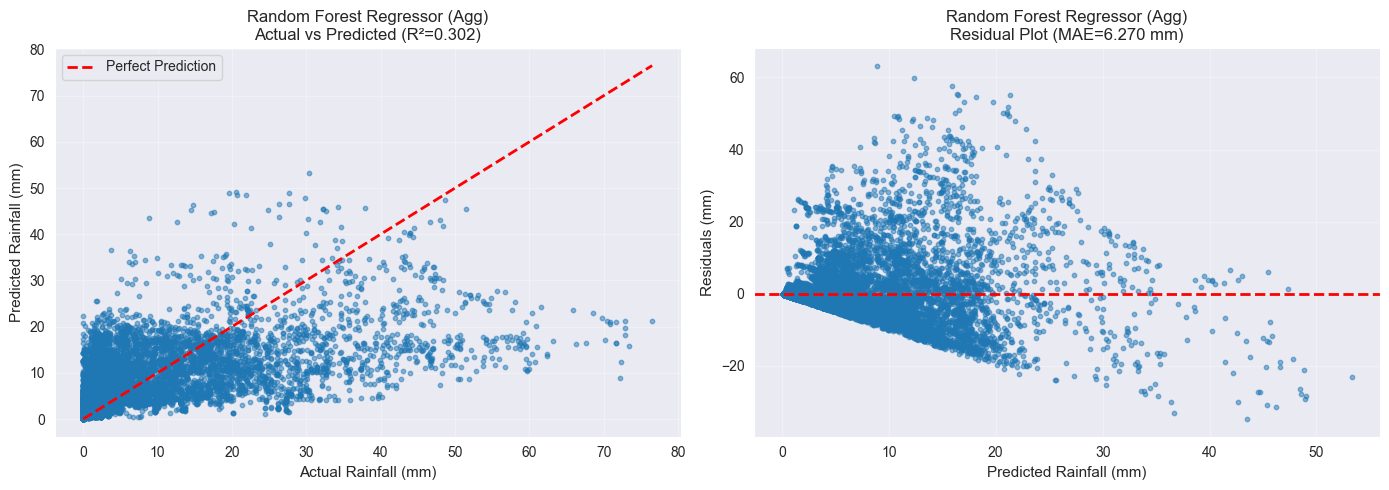

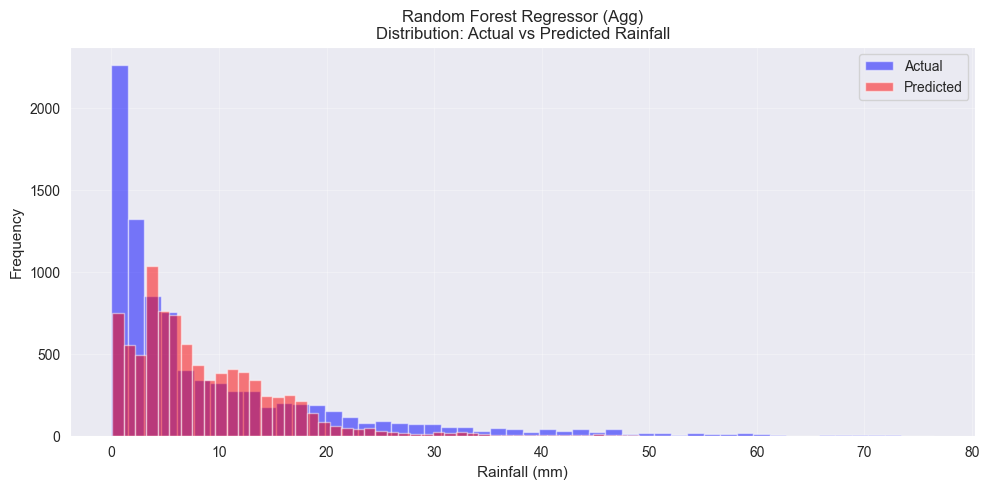

In [ ]:
print("Training Random Forest Regressor with Grid Search...")

# Random Forest Regressor
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_cv = GridSearchCV(
    rf, rf_grid, 
    scoring="neg_mean_squared_error",  # Use RMSE for regression
    cv=3, 
    n_jobs=-1, 
    verbose=1
)

rf_cv.fit(X_train_agg, y_train_agg)
rf_best = rf_cv.best_estimator_

print("\n" + "="*60)
print("Random Forest — Best Hyperparameters:")
print("="*60)
for param, value in rf_cv.best_params_.items():
    print(f"  {param}: {value}")
print("="*60)

# Predictions
y_pred_rf = rf_best.predict(X_test_agg)

# Evaluate
evaluate_regressor("Random Forest Regressor (Agg)", y_test_agg, y_pred_rf)


## Extra Trees Regressor with Grid Search

Training Extra Trees Regressor with Grid Search...
Fitting 3 folds for each of 81 candidates, totalling 243 fits

Extra Trees — Best Hyperparameters:
  max_depth: 15
  min_samples_leaf: 4
  min_samples_split: 10
  n_estimators: 600

Extra Trees Regressor (Agg) — Performance Metrics
  RMSE (Root Mean Squared Error): 9.600 mm
  MAE (Mean Absolute Error):      6.211 mm
  R² Score:                       0.310
  MAPE (Mean Absolute % Error):   264.79%



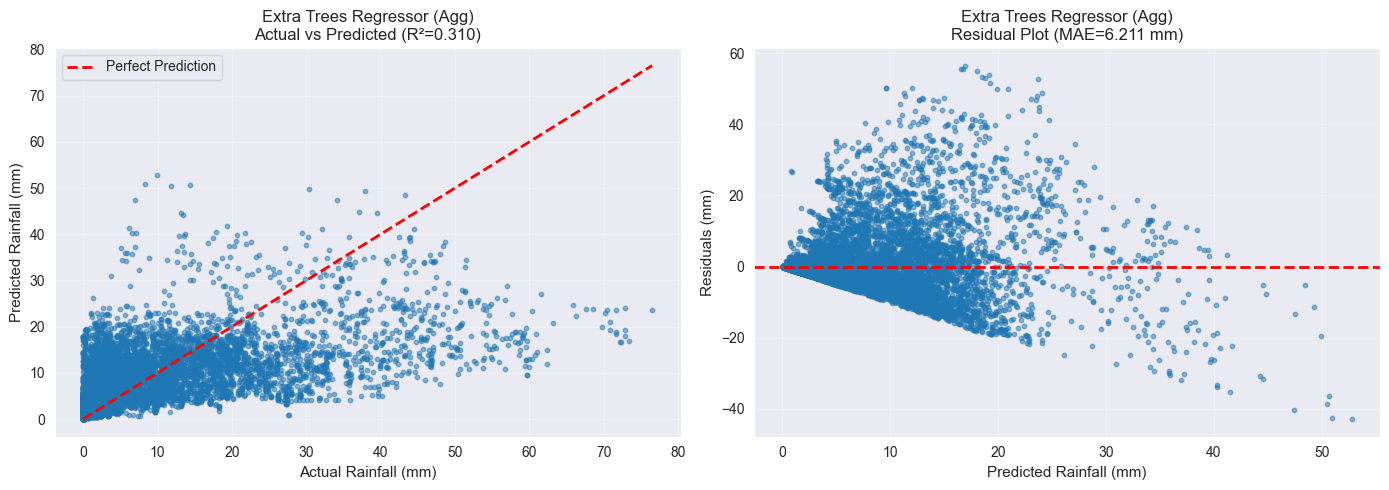

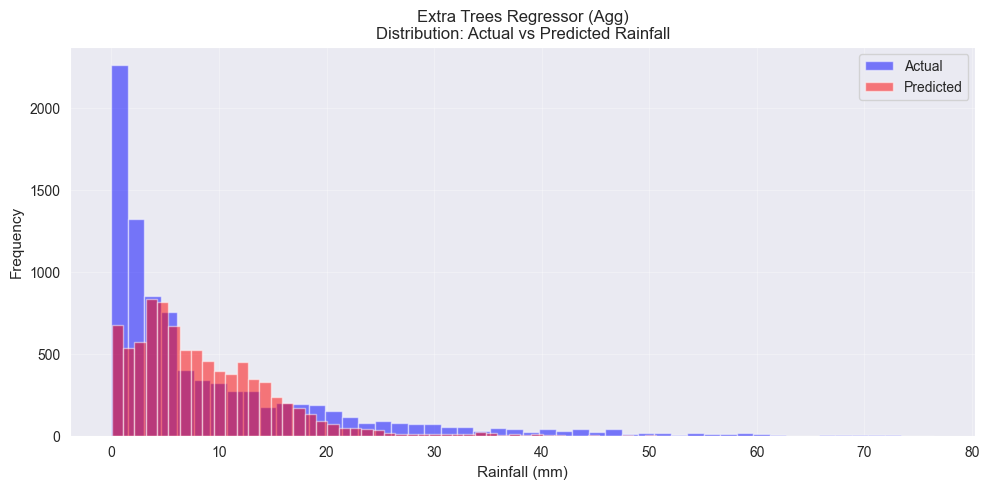

In [ ]:
print("Training Extra Trees Regressor with Grid Search...")

# Extra Trees Regressor
et = ExtraTreesRegressor(random_state=42, n_jobs=-1)
et_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 15, 25],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

et_cv = GridSearchCV(
    et, et_grid, 
    scoring="neg_mean_squared_error",
    cv=3, 
    n_jobs=-1, 
    verbose=1
)

et_cv.fit(X_train_agg, y_train_agg)
et_best = et_cv.best_estimator_

print("\n" + "="*60)
print("Extra Trees — Best Hyperparameters:")
print("="*60)
for param, value in et_cv.best_params_.items():
    print(f"  {param}: {value}")
print("="*60)

# Predictions
y_pred_et = et_best.predict(X_test_agg)

# Evaluate
evaluate_regressor("Extra Trees Regressor (Agg)", y_test_agg, y_pred_et)


## XGBoost Regressor with Grid Search

Training XGBoost Regressor with Grid Search...
Fitting 3 folds for each of 729 candidates, totalling 2187 fits

XGBoost — Best Hyperparameters:
  colsample_bytree: 0.8
  learning_rate: 0.01
  max_depth: 4
  min_child_weight: 5
  n_estimators: 400
  subsample: 0.8

XGBoost Regressor (Agg) — Performance Metrics
  RMSE (Root Mean Squared Error): 9.366 mm
  MAE (Mean Absolute Error):      6.020 mm
  R² Score:                       0.343
  MAPE (Mean Absolute % Error):   248.33%



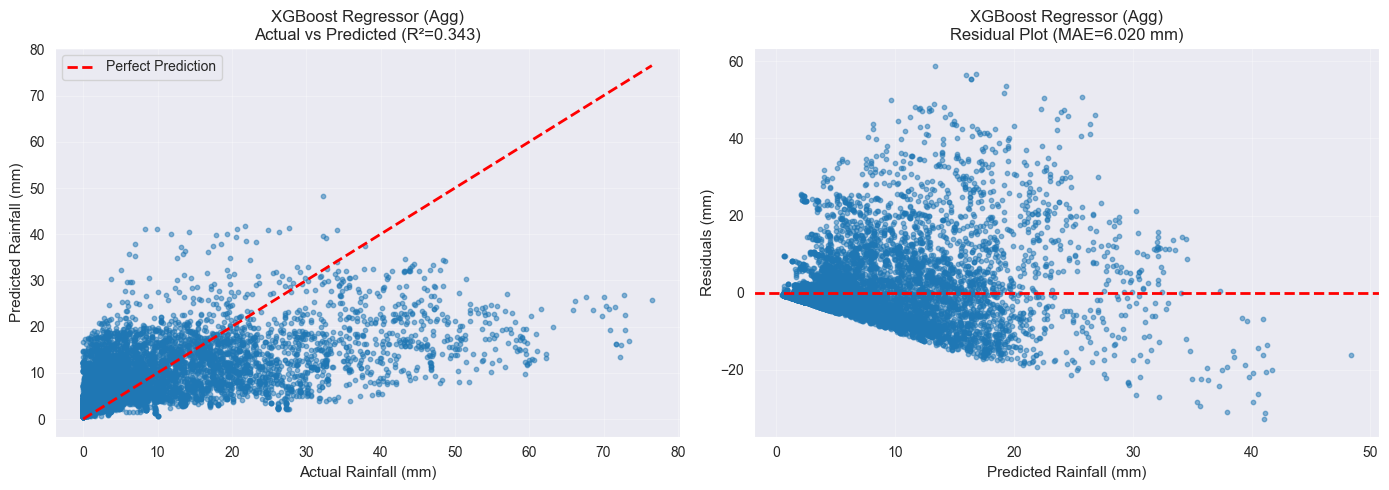

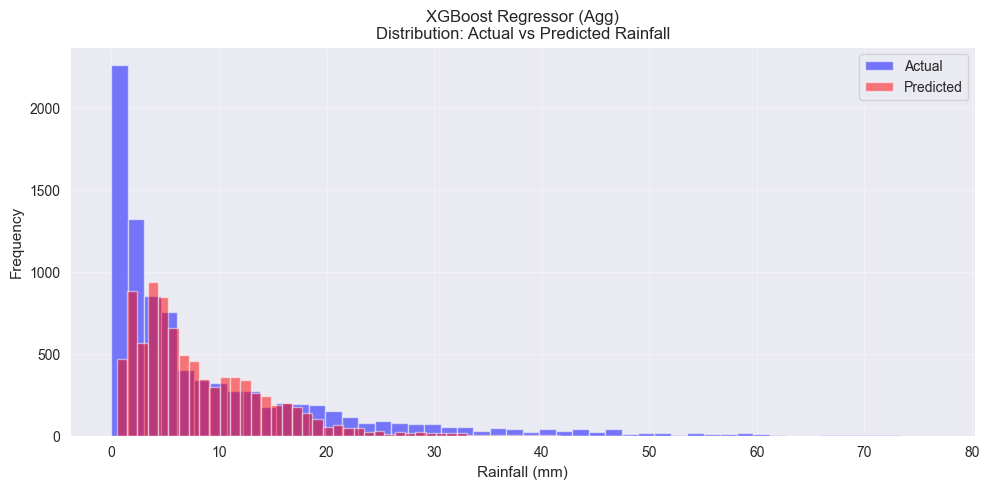

In [15]:
if HAS_XGB:
    print("Training XGBoost Regressor with Grid Search...")
    
    # XGBoost Regressor
    xgb = XGBRegressor(
        objective="reg:squarederror",  # Regression objective
        nthread=-1,
        random_state=42,
        tree_method="hist"  # Fast histogram-based algorithm
    )
    
    xgb_grid = {
        "n_estimators": [200, 400, 600],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.8, 0.9, 1.0],
        "colsample_bytree": [0.8, 0.9, 1.0],
        "min_child_weight": [1, 3, 5]
    }
    
    xgb_cv = GridSearchCV(
        xgb, xgb_grid, 
        scoring="neg_mean_squared_error",
        cv=3, 
        n_jobs=-1, 
        verbose=1
    )
    
    xgb_cv.fit(X_train_agg, y_train_agg)
    xgb_best = xgb_cv.best_estimator_
    
    print("\n" + "="*60)
    print("XGBoost — Best Hyperparameters:")
    print("="*60)
    for param, value in xgb_cv.best_params_.items():
        print(f"  {param}: {value}")
    print("="*60)
    
    # Predictions
    y_pred_xgb = xgb_best.predict(X_test_agg)
    
    # Evaluate
    evaluate_regressor("XGBoost Regressor (Agg)", y_test_agg, y_pred_xgb)
else:
    print("XGBoost not available — skipping.")
    print("Install with: pip install xgboost")


## Gradient Boosting Regressor

Training Gradient Boosting Regressor with Grid Search...
Fitting 3 folds for each of 144 candidates, totalling 432 fits

Gradient Boosting — Best Hyperparameters:
  learning_rate: 0.01
  max_depth: 4
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200
  subsample: 0.8

Gradient Boosting Regressor (Agg) — Performance Metrics
  RMSE (Root Mean Squared Error): 9.499 mm
  MAE (Mean Absolute Error):      6.188 mm
  R² Score:                       0.325
  MAPE (Mean Absolute % Error):   283.61%



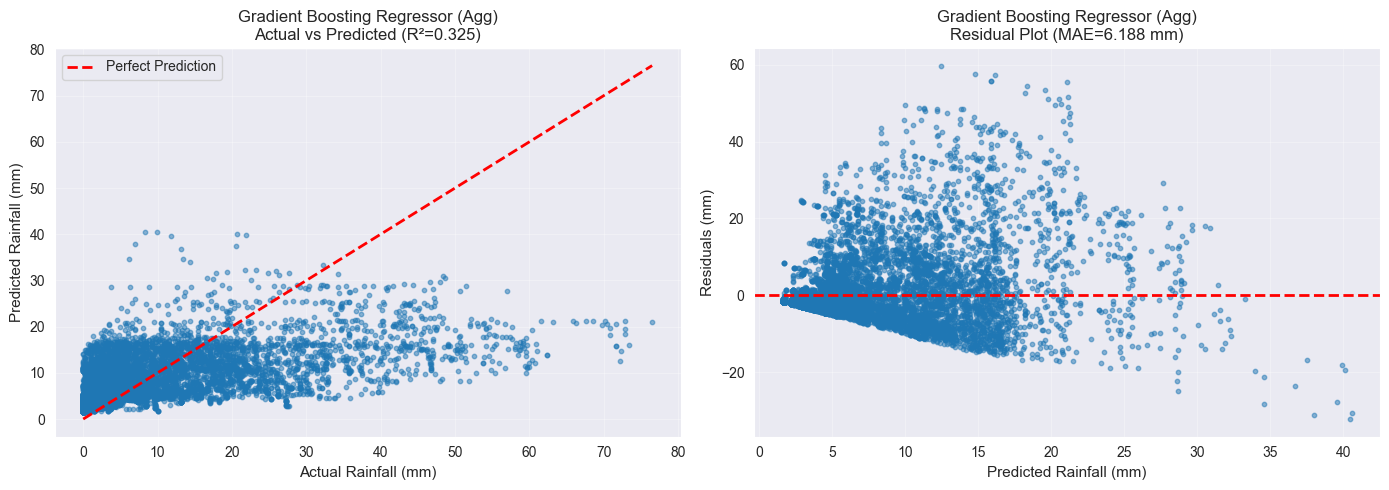

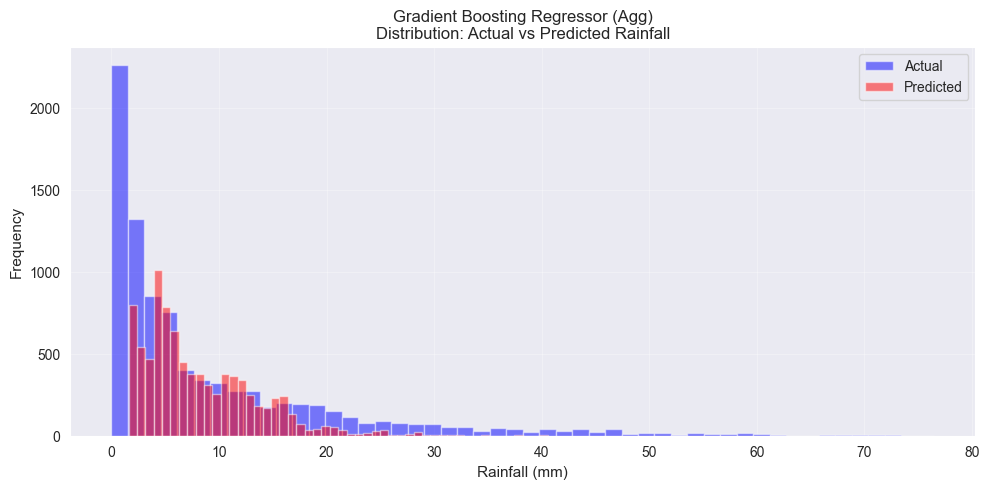

In [16]:
print("Training Gradient Boosting Regressor with Grid Search...")

# Gradient Boosting Regressor (from sklearn, no extra install needed)
gb = GradientBoostingRegressor(random_state=42)
gb_grid = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

gb_cv = GridSearchCV(
    gb, gb_grid, 
    scoring="neg_mean_squared_error",
    cv=3, 
    n_jobs=-1, 
    verbose=1
)

gb_cv.fit(X_train_agg, y_train_agg)
gb_best = gb_cv.best_estimator_

print("\n" + "="*60)
print("Gradient Boosting — Best Hyperparameters:")
print("="*60)
for param, value in gb_cv.best_params_.items():
    print(f"  {param}: {value}")
print("="*60)

# Predictions
y_pred_gb = gb_best.predict(X_test_agg)

# Evaluate
evaluate_regressor("Gradient Boosting Regressor (Agg)", y_test_agg, y_pred_gb)


## Compare All NDL Models

In [28]:
# Create comparison summary
models_comparison = []

if 'y_pred_rf' in locals():
    models_comparison.append({
        'Model': 'Random Forest',
        'RMSE': np.sqrt(mean_squared_error(y_test_agg, y_pred_rf)),
        'MAE': mean_absolute_error(y_test_agg, y_pred_rf),
        'R²': r2_score(y_test_agg, y_pred_rf)
    })

if 'y_pred_et' in locals():
    models_comparison.append({
        'Model': 'Extra Trees',
        'RMSE': np.sqrt(mean_squared_error(y_test_agg, y_pred_et)),
        'MAE': mean_absolute_error(y_test_agg, y_pred_et),
        'R²': r2_score(y_test_agg, y_pred_et)
    })

if 'y_pred_gb' in locals():
    models_comparison.append({
        'Model': 'Gradient Boosting',
        'RMSE': np.sqrt(mean_squared_error(y_test_agg, y_pred_gb)),
        'MAE': mean_absolute_error(y_test_agg, y_pred_gb),
        'R²': r2_score(y_test_agg, y_pred_gb)
    })

if HAS_XGB and 'y_pred_xgb' in locals():
    models_comparison.append({
        'Model': 'XGBoost',
        'RMSE': np.sqrt(mean_squared_error(y_test_agg, y_pred_xgb)),
        'MAE': mean_absolute_error(y_test_agg, y_pred_xgb),
        'R²': r2_score(y_test_agg, y_pred_xgb)
    })

# Create DataFrame and display
df_ndl_comparison = pd.DataFrame(models_comparison)
df_ndl_comparison = df_ndl_comparison.sort_values('RMSE')

print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON (Sorted by RMSE)")
print("="*70)
print(df_ndl_comparison.to_string(index=False))
print("="*70)
print("\nBest Model (Lowest RMSE):", df_ndl_comparison.iloc[0]['Model'])
print(f"Best RMSE: {df_ndl_comparison.iloc[0]['RMSE']:.3f} mm")
print(f"Best MAE: {df_ndl_comparison.iloc[0]['MAE']:.3f} mm")
print(f"Best R²: {df_ndl_comparison.iloc[0]['R²']:.3f}")



MODEL PERFORMANCE COMPARISON (Sorted by RMSE)
            Model     RMSE      MAE       R²
          XGBoost 9.365866 6.020065 0.343396
Gradient Boosting 9.499121 6.187897 0.324580
      Extra Trees 9.600201 6.211129 0.310129
    Random Forest 9.653364 6.269936 0.302467

Best Model (Lowest RMSE): XGBoost
Best RMSE: 9.366 mm
Best MAE: 6.020 mm
Best R²: 0.343


# 5B) Train Sequential models

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

print(f"TensorFlow version: {tf.__version__}")


TensorFlow version: 2.20.0


In [19]:
# Split training data into train/validation (time-aware split)
val_frac = 0.2
cut = int((1 - val_frac) * len(X_train_seq))

X_tr = X_train_seq[:cut]
X_val = X_train_seq[cut:]
y_tr = y_train_seq[:cut]
y_val = y_train_seq[cut:]

print(f"Training sequences: {X_tr.shape}")
print(f"Validation sequences: {X_val.shape}")
print(f"Test sequences: {X_test_seq.shape}")
print(f"\nTarget statistics:")
print(f"  Train: mean={y_tr.mean():.2f}, std={y_tr.std():.2f}, max={y_tr.max():.2f}")
print(f"  Val:   mean={y_val.mean():.2f}, std={y_val.std():.2f}, max={y_val.max():.2f}")
print(f"  Test:  mean={y_test_seq.mean():.2f}, std={y_test_seq.std():.2f}, max={y_test_seq.max():.2f}")


Training sequences: (28032, 24, 2)
Validation sequences: (7008, 24, 2)
Test sequences: (8760, 24, 2)

Target statistics:
  Train: mean=7.21, std=10.61, max=142.60
  Val:   mean=11.04, std=10.81, max=77.90
  Test:  mean=9.03, std=11.56, max=76.50


In [20]:
def get_callbacks(model_name):
    """Create callbacks for training"""
    return [
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            patience=5,
            factor=0.5,
            min_lr=1e-6,
            verbose=1
        ),
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ModelCheckpoint(
            f'best_{model_name}.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=0
        )
    ]


## Model 1 - Simple LSTM Regressor (Baseline)

MODEL 1: Simple LSTM Regressor (Baseline)



Model: "Simple_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,425 (91.50 KB)

 Trainable params: 23,425 (91.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 100.4702 - mae: 5.8984 - val_loss: 88.9717 - val_mae: 6.4684 - learning_rate: 0.0010
Epoch 2/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 87.6557 - mae: 5.3090 - val_loss: 89.1914 - val_mae: 6.3793 - learning_rate: 0.0010
Epoch 3/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 86.8301 - mae: 5.2805 - val_loss: 91.1890 - val_mae: 6.4299 - learning_rate: 0.0010
Epoch 4/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 86.1147 - mae: 5.2441 - val_loss: 89.3538 - val_mae: 6.3942 - learning_rate: 0.0010
Epoch 5/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 86.1824 - mae: 5.2425 - val_loss: 92.8205 - val_mae: 6.3633 - learning_rate: 0.0010
Epoch 6/50
427/438 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 80.2912 - mae: 5.1566
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 85.5036 - mae: 5.2288 - val_loss: 90.7428 - val_mae: 6.4154 - learning_r

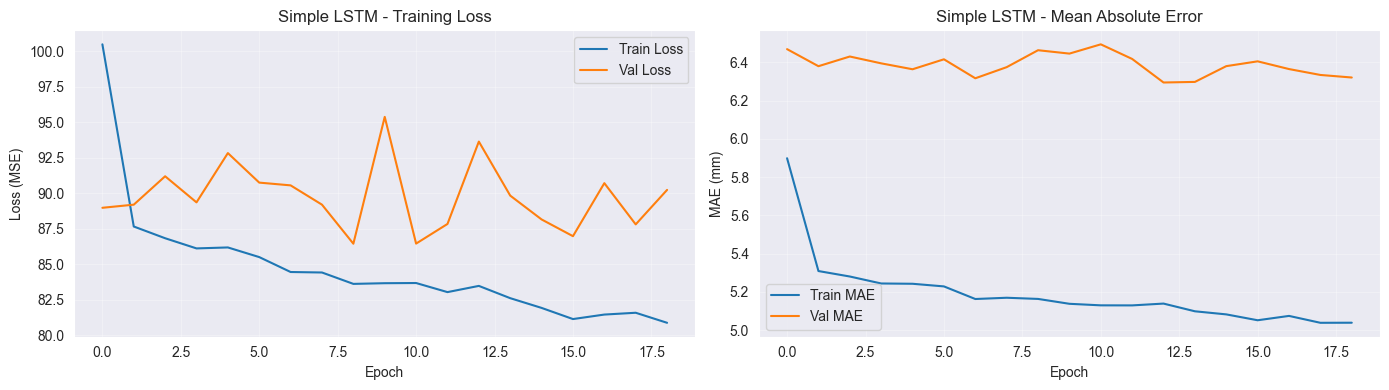

In [21]:
print("="*70)
print("MODEL 1: Simple LSTM Regressor (Baseline)")
print("="*70)

tf.keras.backend.clear_session()

model_simple_lstm = models.Sequential([
    layers.Input(shape=(WINDOW_H, 2)),
    layers.LSTM(64, return_sequences=False),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1)  # Single output for rainfall amount (regression)
], name="Simple_LSTM")

model_simple_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model_simple_lstm.summary()

# Train
history_simple = model_simple_lstm.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=get_callbacks('simple_lstm'),
    verbose=1
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_simple.history["loss"], label="Train Loss")
axes[0].plot(history_simple.history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("Simple LSTM - Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_simple.history["mae"], label="Train MAE")
axes[1].plot(history_simple.history["val_mae"], label="Val MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (mm)")
axes[1].set_title("Simple LSTM - Mean Absolute Error")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Model 2 - Stacked Bidirectional LSTM

MODEL 2: Stacked Bidirectional LSTM


Model: "Bidirectional_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 24, 256)        │       134,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 24, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 345,985 (1.32 MB)

 Trainable params: 345,985 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - loss: 99.3146 - mae: 5.9453 - val_loss: 88.5708 - val_mae: 6.7628 - learning_rate: 0.0010
Epoch 2/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 88.4623 - mae: 5.4847 - val_loss: 91.6499 - val_mae: 6.3617 - learning_rate: 0.0010
Epoch 3/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - loss: 86.9738 - mae: 5.3489 - val_loss: 93.8904 - val_mae: 6.4222 - learning_rate: 0.0010
Epoch 4/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 85.5730 - mae: 5.3067 - val_loss: 87.2328 - val_mae: 6.5547 - learning_rate: 0.0010
Epoch 5/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 85.3803 - mae: 5.2674 - val_loss: 87.8195 - val_mae: 6.5353 - learning_rate: 0.0010
Epoch 6/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - loss: 84.1438 - mae: 5.2345 - val_loss: 103.2554 - val_mae: 6.4849 - learning_rate: 0.0010
Epoch 7/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - loss: 84.2975 - mae: 5.2394 - val_loss: 86.2797 - val_mae: 6.6291 -

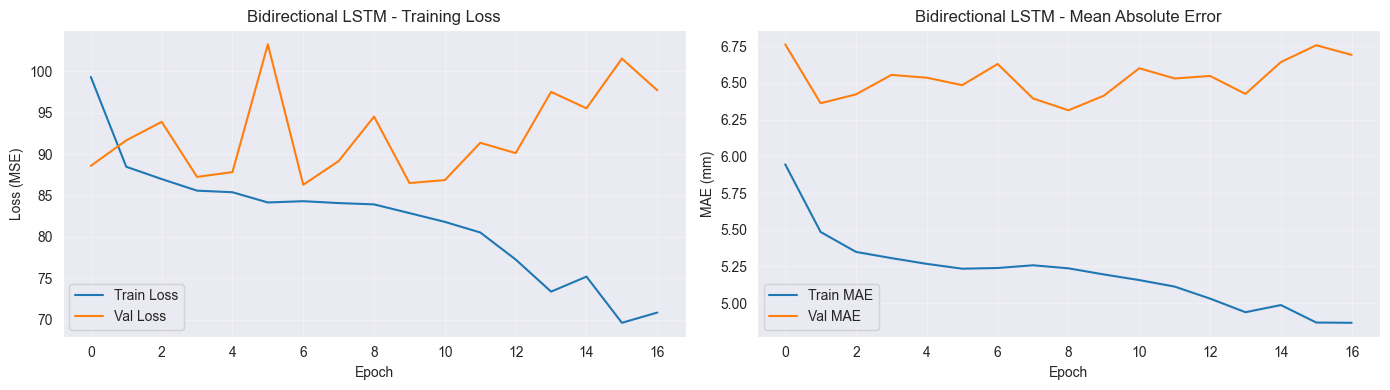

In [22]:
print("="*70)
print("MODEL 2: Stacked Bidirectional LSTM")
print("="*70)

tf.keras.backend.clear_session()

model_bilstm = models.Sequential([
    layers.Input(shape=(WINDOW_H, 2)),
    layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
    layers.Dropout(0.3),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.Dropout(0.3),
    layers.Bidirectional(layers.LSTM(32, return_sequences=False)),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
], name="Bidirectional_LSTM")

model_bilstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model_bilstm.summary()

# Train
history_bilstm = model_bilstm.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=get_callbacks('bilstm'),
    verbose=1
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_bilstm.history["loss"], label="Train Loss")
axes[0].plot(history_bilstm.history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("Bidirectional LSTM - Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_bilstm.history["mae"], label="Train MAE")
axes[1].plot(history_bilstm.history["val_mae"], label="Val MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (mm)")
axes[1].set_title("Bidirectional LSTM - Mean Absolute Error")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Model 3 - LSTM with Attention Mechanism

MODEL 3: LSTM with Attention Mechanism


Model: "LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 24, 128)        │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 64)             │         4,160 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,913 (495.75 KB)

 Trainable params: 126,913 (495.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 107.7588 - mae: 6.3379 - val_loss: 99.6557 - val_mae: 6.4897 - learning_rate: 0.0010
Epoch 2/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 89.6641 - mae: 5.4954 - val_loss: 88.6670 - val_mae: 6.5584 - learning_rate: 0.0010
Epoch 3/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 86.3140 - mae: 5.3206 - val_loss: 92.7090 - val_mae: 6.2958 - learning_rate: 0.0010
Epoch 4/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 84.8462 - mae: 5.2580 - val_loss: 88.1158 - val_mae: 6.3535 - learning_rate: 0.0010
Epoch 5/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 83.3376 - mae: 5.2134 - val_loss: 89.1376 - val_mae: 6.4768 - learning_rate: 0.0010
Epoch 6/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 81.1760 - mae: 5.1426 - val_loss: 96.1459 - val_mae: 6.5179 - learning_rate: 0.0010
Epoch 7/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 79.3072 - mae: 5.0993 - val_loss: 94.6122 - val_mae: 6.4087 - learni

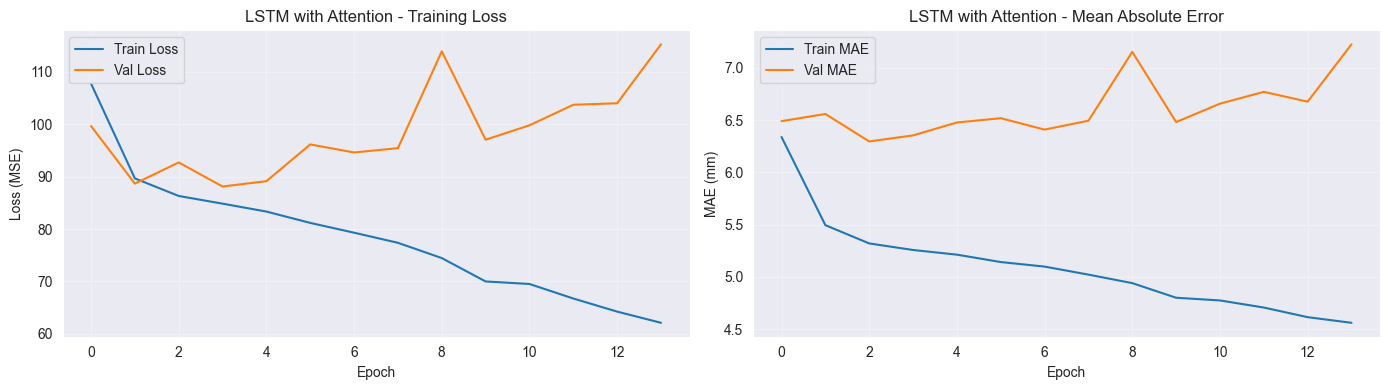

In [23]:
print("="*70)
print("MODEL 3: LSTM with Attention Mechanism")
print("="*70)

tf.keras.backend.clear_session()

# Custom Attention Layer
class AttentionLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
    
    def build(self, input_shape):
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], input_shape[-1]),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='attention_bias',
            shape=(input_shape[-1],),
            initializer='zeros',
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)
    
    def call(self, x):
        # Compute attention scores
        e = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        a = tf.nn.softmax(e, axis=1)
        # Apply attention weights
        output = x * a
        return tf.reduce_sum(output, axis=1)

# Build model with attention
inputs = layers.Input(shape=(WINDOW_H, 2))
x = layers.LSTM(128, return_sequences=True)(inputs)
x = layers.Dropout(0.3)(x)
x = layers.LSTM(64, return_sequences=True)(x)
x = layers.Dropout(0.3)(x)
x = AttentionLayer()(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation="relu")(x)
outputs = layers.Dense(1)(x)

model_attention = models.Model(inputs=inputs, outputs=outputs, name="LSTM_Attention")

model_attention.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model_attention.summary()

# Train
history_attention = model_attention.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=get_callbacks('lstm_attention'),
    verbose=1
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_attention.history["loss"], label="Train Loss")
axes[0].plot(history_attention.history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("LSTM with Attention - Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_attention.history["mae"], label="Train MAE")
axes[1].plot(history_attention.history["val_mae"], label="Val MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (mm)")
axes[1].set_title("LSTM with Attention - Mean Absolute Error")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Model 4 - CNN-LSTM Hybrid

MODEL 4: CNN-LSTM Hybrid


Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 24, 64)         │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 24, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 12, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,809 (655.50 KB)

 Trainable params: 167,553 (654.50 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 89.7758 - mae: 5.3172 - val_loss: 92.1398 - val_mae: 7.6083 - learning_rate: 0.0010
Epoch 2/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 83.9920 - mae: 5.1460 - val_loss: 88.5085 - val_mae: 7.2161 - learning_rate: 0.0010
Epoch 3/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 81.6493 - mae: 5.0857 - val_loss: 171.7747 - val_mae: 11.5908 - learning_rate: 0.0010
Epoch 4/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 78.5481 - mae: 4.9908 - val_loss: 153.0677 - val_mae: 8.0525 - learning_rate: 0.0010
Epoch 5/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 74.1396 - mae: 4.8797 - val_loss: 111.0082 - val_mae: 7.9195 - learning_rate: 0.0010
Epoch 6/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 70.1338 - mae: 4.8260 - val_loss: 91.1992 - val_mae: 6.5255 - learning_rate: 0.0010
Epoch 7/50
437/438 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 64.6544 - mae: 4.6378
Epoch 7: ReduceLROnPlateau reducing learnin

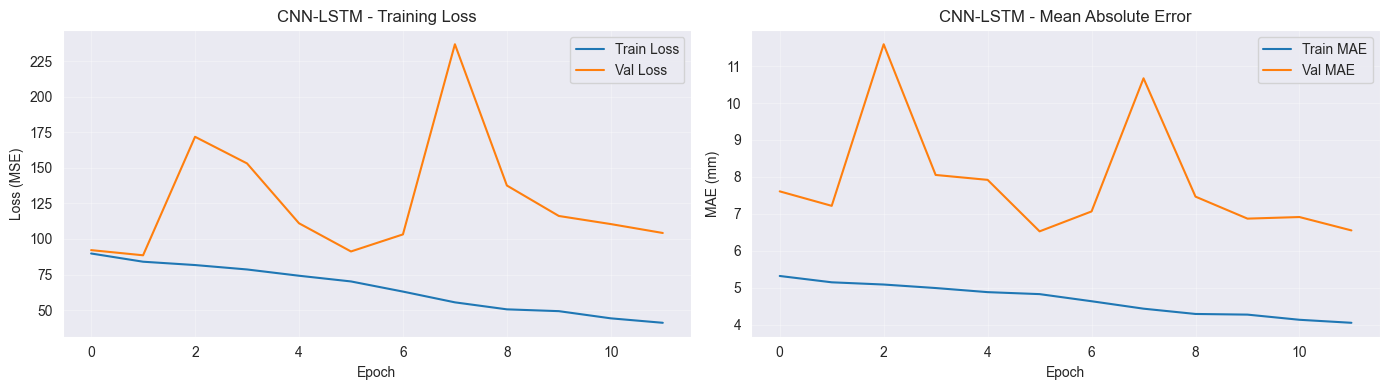

In [24]:
print("="*70)
print("MODEL 4: CNN-LSTM Hybrid")
print("="*70)

tf.keras.backend.clear_session()

model_cnn_lstm = models.Sequential([
    layers.Input(shape=(WINDOW_H, 2)),
    # CNN layers for feature extraction
    layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),
    # LSTM layers for temporal dependencies
    layers.LSTM(128, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.3),
    # Dense layers
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
], name="CNN_LSTM")

model_cnn_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model_cnn_lstm.summary()

# Train
history_cnn_lstm = model_cnn_lstm.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=get_callbacks('cnn_lstm'),
    verbose=1
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_cnn_lstm.history["loss"], label="Train Loss")
axes[0].plot(history_cnn_lstm.history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("CNN-LSTM - Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_cnn_lstm.history["mae"], label="Train MAE")
axes[1].plot(history_cnn_lstm.history["val_mae"], label="Val MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (mm)")
axes[1].set_title("CNN-LSTM - Mean Absolute Error")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Model 5 - GRU with Residual Connections

MODEL 5: GRU with Residual Connections


Model: "GRU_Residual"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 24, 128)   │     50,688 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 128)   │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 24, 128)   │     99,072 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 128)   │          0 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 128)   │          0 │ dropout[0][0],    │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 64)        │     37,248 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 193,281 (755.00 KB)

 Trainable params: 193,281 (755.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 97.7990 - mae: 5.9302 - val_loss: 89.8796 - val_mae: 6.2880 - learning_rate: 0.0010
Epoch 2/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 88.1246 - mae: 5.4441 - val_loss: 95.9861 - val_mae: 6.3952 - learning_rate: 0.0010
Epoch 3/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 86.3760 - mae: 5.3651 - val_loss: 97.2811 - val_mae: 6.4057 - learning_rate: 0.0010
Epoch 4/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 85.8137 - mae: 5.3279 - val_loss: 98.6048 - val_mae: 6.4104 - learning_rate: 0.0010
Epoch 5/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 84.1180 - mae: 5.2405 - val_loss: 90.4018 - val_mae: 6.7587 - learning_rate: 0.0010
Epoch 6/50
436/438 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 89.3639 - mae: 5.3066
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
438/438 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 83.3881 - mae: 5.2280 - val_loss: 94.9490 - val_mae: 6.3733 -

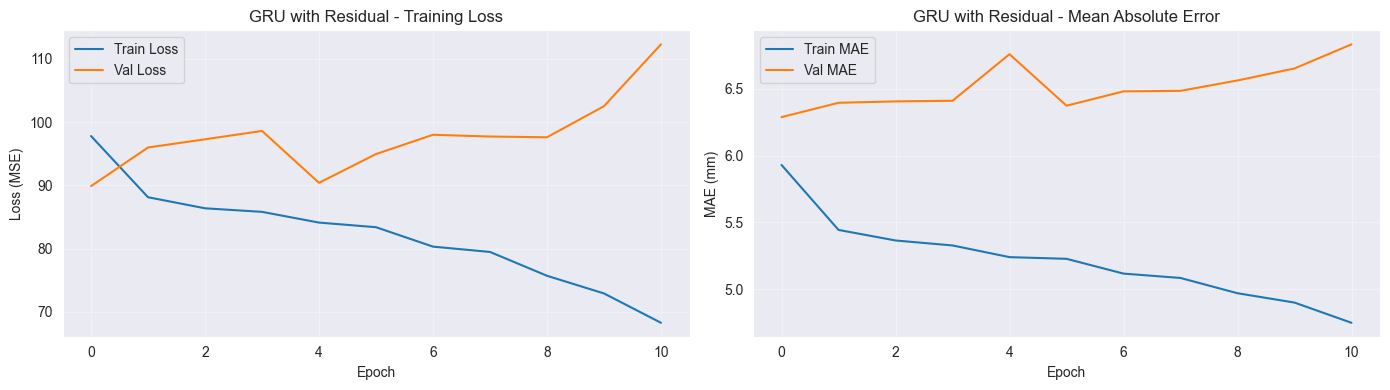

In [25]:
print("="*70)
print("MODEL 5: GRU with Residual Connections")
print("="*70)

tf.keras.backend.clear_session()

# Input
inputs = layers.Input(shape=(WINDOW_H, 2))

# First GRU block
x1 = layers.GRU(128, return_sequences=True)(inputs)
x1 = layers.Dropout(0.3)(x1)

# Second GRU block with residual connection
x2 = layers.GRU(128, return_sequences=True)(x1)
x2 = layers.Dropout(0.3)(x2)
x2_res = layers.Add()([x1, x2])  # Residual connection

# Third GRU block
x3 = layers.GRU(64, return_sequences=False)(x2_res)
x3 = layers.Dropout(0.3)(x3)

# Dense layers
x = layers.Dense(64, activation="relu")(x3)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation="relu")(x)
outputs = layers.Dense(1)(x)

model_gru_res = models.Model(inputs=inputs, outputs=outputs, name="GRU_Residual")

model_gru_res.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model_gru_res.summary()

# Train
history_gru_res = model_gru_res.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=get_callbacks('gru_residual'),
    verbose=1
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_gru_res.history["loss"], label="Train Loss")
axes[0].plot(history_gru_res.history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("GRU with Residual - Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_gru_res.history["mae"], label="Train MAE")
axes[1].plot(history_gru_res.history["val_mae"], label="Val MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (mm)")
axes[1].set_title("GRU with Residual - Mean Absolute Error")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Evaluate All Deep Learning Models


EVALUATING ALL DEEP LEARNING MODELS ON TEST SET


Evaluating: Simple LSTM
  RMSE: 9.263 mm
  MAE:  6.181 mm
  R²:   0.358


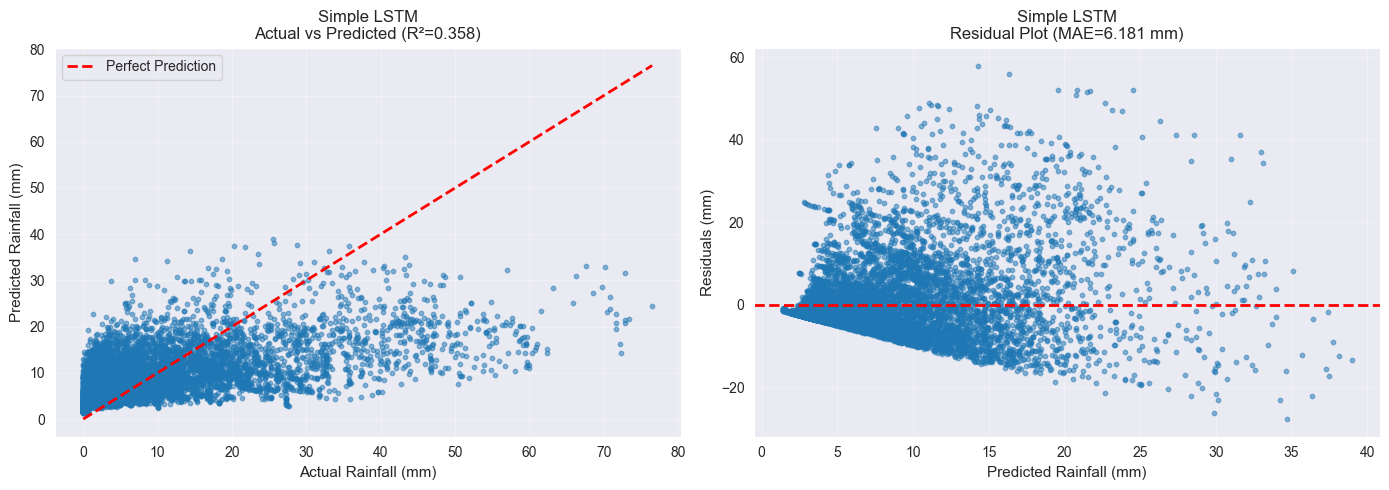


Evaluating: Bidirectional LSTM
  RMSE: 9.202 mm
  MAE:  6.320 mm
  R²:   0.366


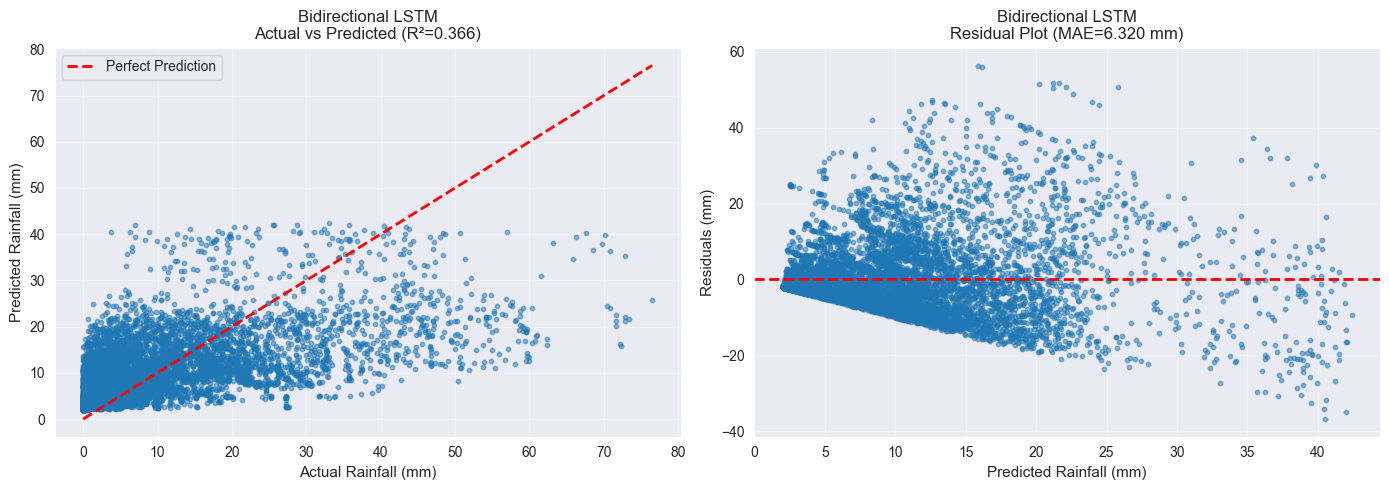


Evaluating: LSTM with Attention
  RMSE: 9.183 mm
  MAE:  5.985 mm
  R²:   0.369


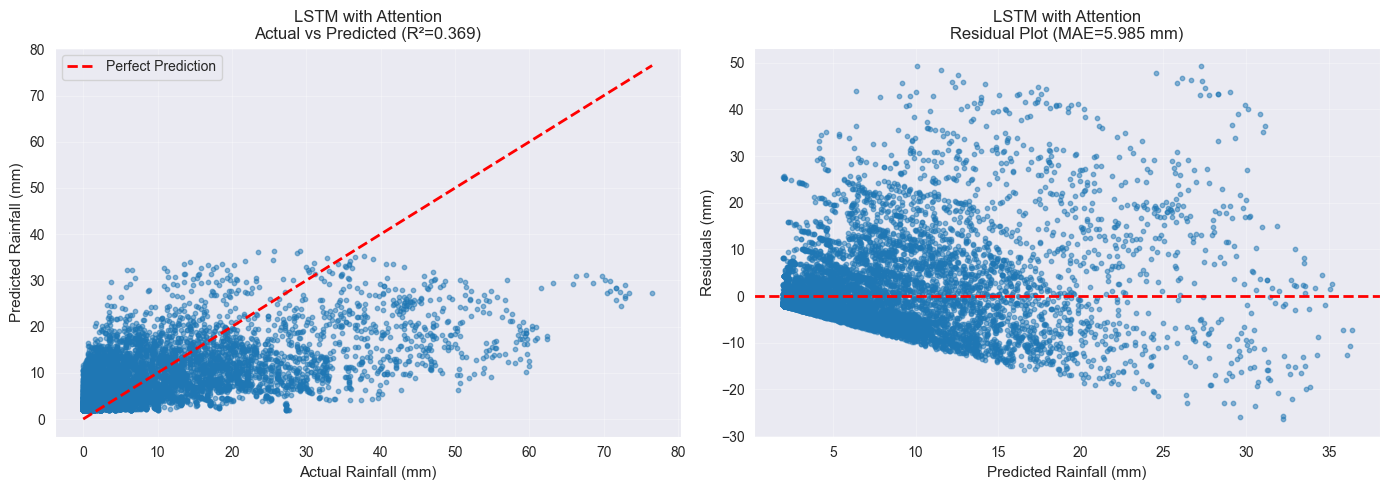


Evaluating: CNN-LSTM Hybrid
  RMSE: 9.502 mm
  MAE:  6.920 mm
  R²:   0.324


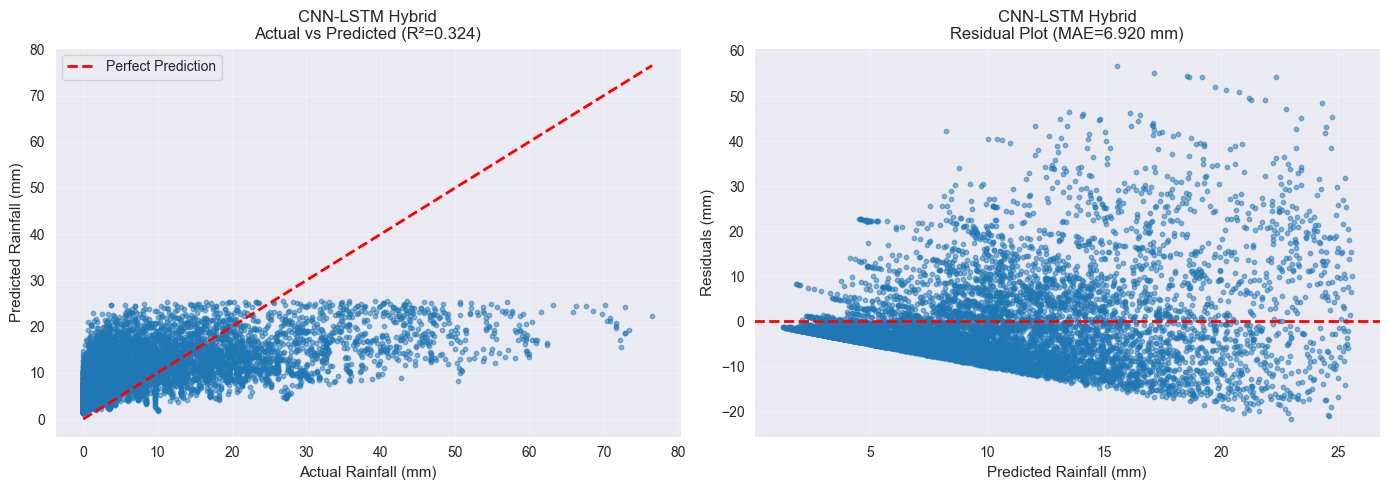


Evaluating: GRU with Residual
  RMSE: 9.488 mm
  MAE:  6.076 mm
  R²:   0.326


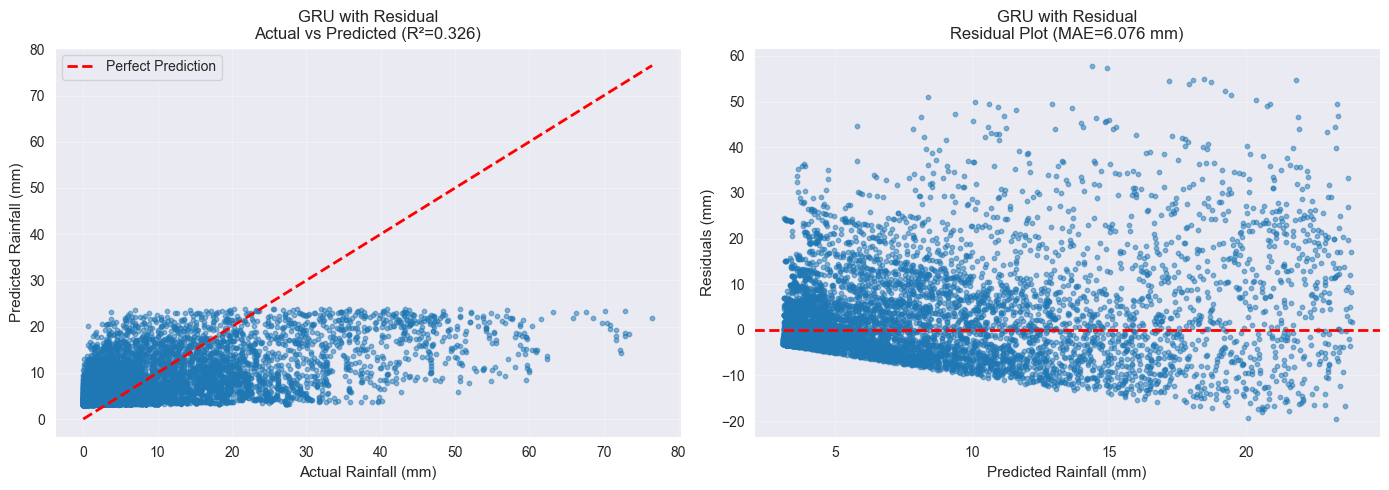

In [26]:
print("\n" + "="*70)
print("EVALUATING ALL DEEP LEARNING MODELS ON TEST SET")
print("="*70 + "\n")

# Dictionary to store models and their predictions
dl_models = {
    "Simple LSTM": model_simple_lstm,
    "Bidirectional LSTM": model_bilstm,
    "LSTM with Attention": model_attention,
    "CNN-LSTM Hybrid": model_cnn_lstm,
    "GRU with Residual": model_gru_res
}

# Store results
dl_results = []

for model_name, model in dl_models.items():
    print(f"\n{'='*70}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*70}")
    
    # Predict on test set
    y_pred = model.predict(X_test_seq, verbose=0).flatten()
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred))
    mae = mean_absolute_error(y_test_seq, y_pred)
    r2 = r2_score(y_test_seq, y_pred)
    
    # Store results
    dl_results.append({
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    })
    
    print(f"  RMSE: {rmse:.3f} mm")
    print(f"  MAE:  {mae:.3f} mm")
    print(f"  R²:   {r2:.3f}")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Actual vs Predicted
    axes[0].scatter(y_test_seq, y_pred, alpha=0.5, s=10)
    axes[0].plot([y_test_seq.min(), y_test_seq.max()], 
                 [y_test_seq.min(), y_test_seq.max()], 
                 'r--', lw=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual Rainfall (mm)', fontsize=11)
    axes[0].set_ylabel('Predicted Rainfall (mm)', fontsize=11)
    axes[0].set_title(f'{model_name}\nActual vs Predicted (R²={r2:.3f})', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Residuals
    residuals = y_test_seq - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.5, s=10)
    axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[1].set_xlabel('Predicted Rainfall (mm)', fontsize=11)
    axes[1].set_ylabel('Residuals (mm)', fontsize=11)
    axes[1].set_title(f'{model_name}\nResidual Plot (MAE={mae:.3f} mm)', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## Compare All Deep Learning Models


DEEP LEARNING MODELS PERFORMANCE COMPARISON (Sorted by RMSE)
              Model     RMSE      MAE       R²
LSTM with Attention 9.183182 5.984541 0.368761
 Bidirectional LSTM 9.201987 6.319782 0.366173
        Simple LSTM 9.262810 6.181426 0.357767
  GRU with Residual 9.487725 6.075995 0.326199
    CNN-LSTM Hybrid 9.501995 6.919502 0.324171

Best Model: LSTM with Attention
Best RMSE: 9.183 mm
Best MAE:  5.985 mm
Best R²:   0.369


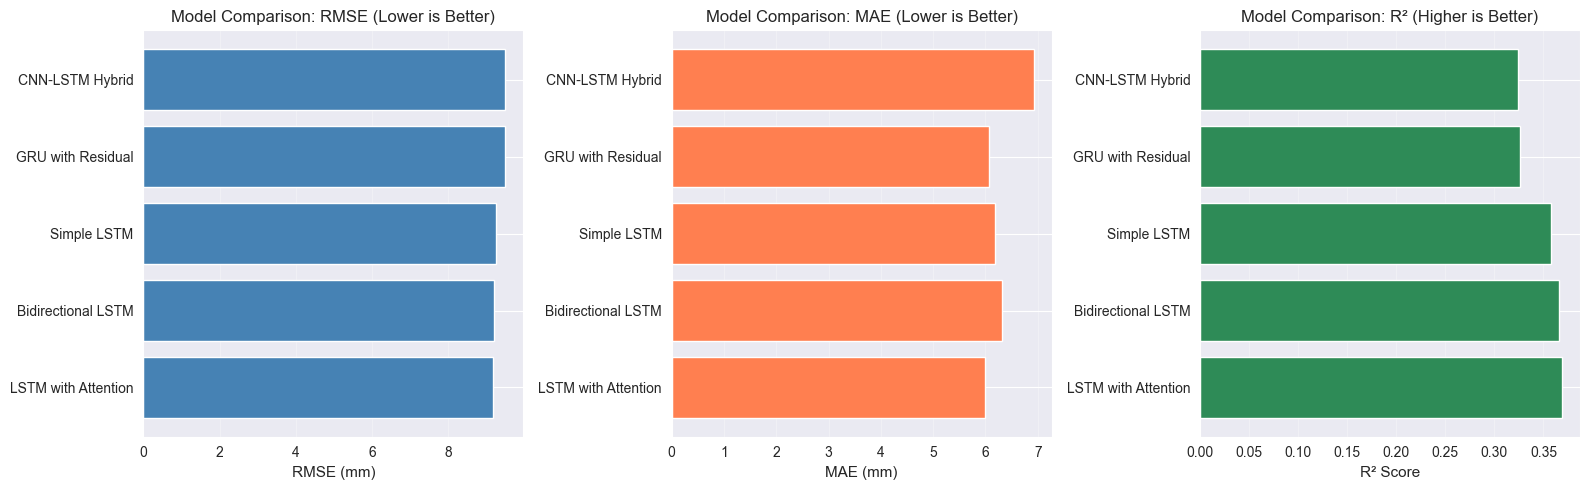

In [27]:
# Create comparison DataFrame
df_dl_comparison = pd.DataFrame(dl_results)
df_dl_comparison = df_dl_comparison.sort_values('RMSE')

print("\n" + "="*70)
print("DEEP LEARNING MODELS PERFORMANCE COMPARISON (Sorted by RMSE)")
print("="*70)
print(df_dl_comparison.to_string(index=False))
print("="*70)

print(f"\nBest Model: {df_dl_comparison.iloc[0]['Model']}")
print(f"Best RMSE: {df_dl_comparison.iloc[0]['RMSE']:.3f} mm")
print(f"Best MAE:  {df_dl_comparison.iloc[0]['MAE']:.3f} mm")
print(f"Best R²:   {df_dl_comparison.iloc[0]['R²']:.3f}")

# Visualization: Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RMSE comparison
axes[0].barh(df_dl_comparison['Model'], df_dl_comparison['RMSE'], color='steelblue')
axes[0].set_xlabel('RMSE (mm)', fontsize=11)
axes[0].set_title('Model Comparison: RMSE (Lower is Better)', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='x')

# MAE comparison
axes[1].barh(df_dl_comparison['Model'], df_dl_comparison['MAE'], color='coral')
axes[1].set_xlabel('MAE (mm)', fontsize=11)
axes[1].set_title('Model Comparison: MAE (Lower is Better)', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='x')

# R² comparison
axes[2].barh(df_dl_comparison['Model'], df_dl_comparison['R²'], color='seagreen')
axes[2].set_xlabel('R² Score', fontsize=11)
axes[2].set_title('Model Comparison: R² (Higher is Better)', fontsize=12)
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


# 6) Comprehensive Comparison - All Models (NDL + DL)

In [30]:
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON: NON-DEEP LEARNING vs DEEP LEARNING")
print("="*80 + "\n")

# Combine both NDL and DL results
df_ndl_comparison['Type'] = 'Non-Deep Learning'
df_dl_comparison['Type'] = 'Deep Learning'

# Concatenate all results
df_all_models = pd.concat([df_ndl_comparison, df_dl_comparison], ignore_index=True)
df_all_models_sorted = df_all_models.sort_values('RMSE')

# Display full comparison
print("ALL MODELS RANKED BY RMSE:")
print("-" * 80)
print(df_all_models_sorted.to_string(index=False))
print("="*80)

# Best overall model
best_overall = df_all_models_sorted.iloc[0]
print(f"\nBEST OVERALL MODEL: {best_overall['Model']} ({best_overall['Type']})")
print(f"   RMSE: {best_overall['RMSE']:.3f} mm")
print(f"   MAE:  {best_overall['MAE']:.3f} mm")
print(f"   R²:   {best_overall['R²']:.3f}")

# Best NDL model
best_ndl = df_ndl_comparison.iloc[0]
print(f"\nBEST NON-DEEP LEARNING MODEL: {best_ndl['Model']}")
print(f"   RMSE: {best_ndl['RMSE']:.3f} mm")
print(f"   MAE:  {best_ndl['MAE']:.3f} mm")
print(f"   R²:   {best_ndl['R²']:.3f}")

# Best DL model
best_dl = df_dl_comparison.iloc[0]
print(f"\nBEST DEEP LEARNING MODEL: {best_dl['Model']}")
print(f"   RMSE: {best_dl['RMSE']:.3f} mm")
print(f"   MAE:  {best_dl['MAE']:.3f} mm")
print(f"   R²:   {best_dl['R²']:.3f}")

# Category statistics
print(f"\n" + "="*80)
print("CATEGORY STATISTICS:")
print("-" * 80)
print(f"Non-Deep Learning Models:")
print(f"  Average RMSE: {df_ndl_comparison['RMSE'].mean():.3f} mm")
print(f"  Average MAE:  {df_ndl_comparison['MAE'].mean():.3f} mm")
print(f"  Average R²:   {df_ndl_comparison['R²'].mean():.3f}")

print(f"\nDeep Learning Models:")
print(f"  Average RMSE: {df_dl_comparison['RMSE'].mean():.3f} mm")
print(f"  Average MAE:  {df_dl_comparison['MAE'].mean():.3f} mm")
print(f"  Average R²:   {df_dl_comparison['R²'].mean():.3f}")
print("="*80)



COMPREHENSIVE MODEL COMPARISON: NON-DEEP LEARNING vs DEEP LEARNING

ALL MODELS RANKED BY RMSE:
--------------------------------------------------------------------------------
              Model     RMSE      MAE       R²              Type
LSTM with Attention 9.183182 5.984541 0.368761     Deep Learning
 Bidirectional LSTM 9.201987 6.319782 0.366173     Deep Learning
        Simple LSTM 9.262810 6.181426 0.357767     Deep Learning
            XGBoost 9.365866 6.020065 0.343396 Non-Deep Learning
  GRU with Residual 9.487725 6.075995 0.326199     Deep Learning
  Gradient Boosting 9.499121 6.187897 0.324580 Non-Deep Learning
    CNN-LSTM Hybrid 9.501995 6.919502 0.324171     Deep Learning
        Extra Trees 9.600201 6.211129 0.310129 Non-Deep Learning
      Random Forest 9.653364 6.269936 0.302467 Non-Deep Learning

BEST OVERALL MODEL: LSTM with Attention (Deep Learning)
   RMSE: 9.183 mm
   MAE:  5.985 mm
   R²:   0.369

BEST NON-DEEP LEARNING MODEL: XGBoost
   RMSE: 9.366 mm
   MAE: 

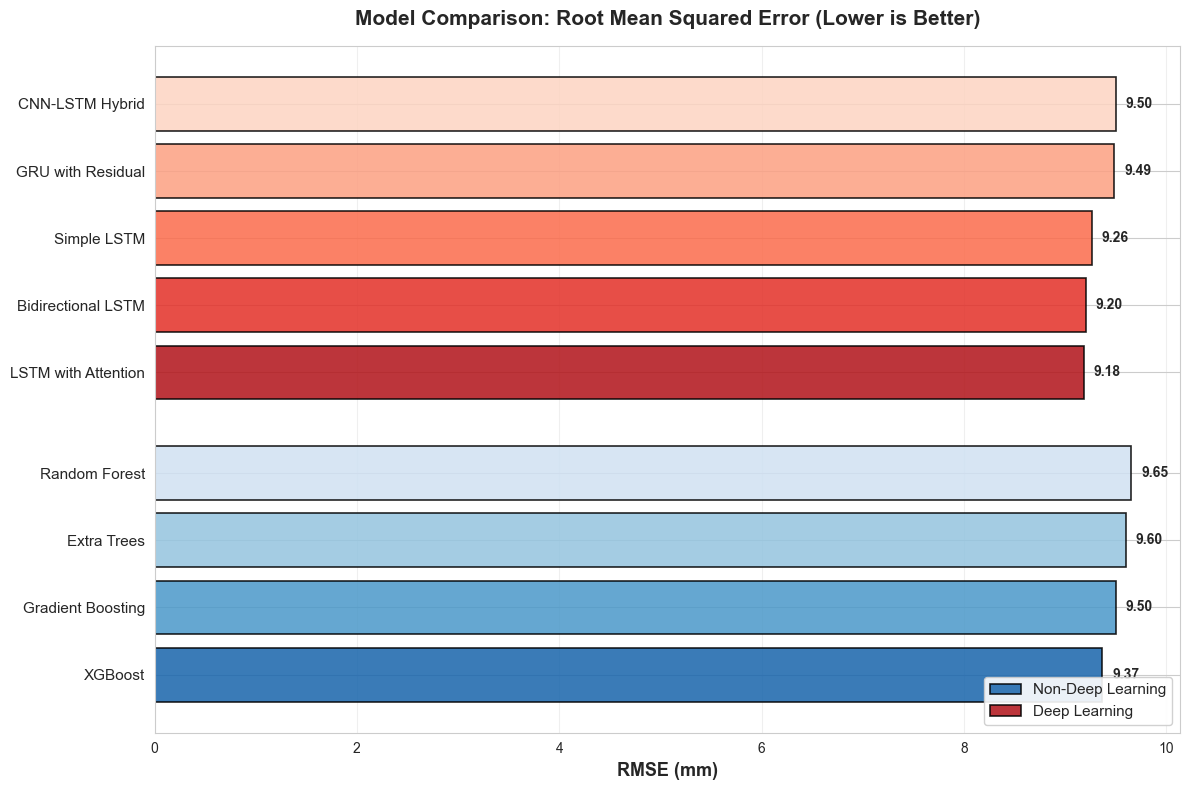

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Color mapping
colors_ndl = sns.color_palette("Blues_r", n_colors=len(df_ndl_comparison))
colors_dl = sns.color_palette("Reds_r", n_colors=len(df_dl_comparison))

# Position setup
y_pos_ndl = np.arange(len(df_ndl_comparison))
y_pos_dl = np.arange(len(df_dl_comparison)) + len(df_ndl_comparison) + 0.5

# Create horizontal bars
bars_ndl = ax.barh(y_pos_ndl, df_ndl_comparison['RMSE'], 
                   color=colors_ndl, edgecolor='black', linewidth=1.2, 
                   label='Non-Deep Learning', alpha=0.85)
bars_dl = ax.barh(y_pos_dl, df_dl_comparison['RMSE'], 
                  color=colors_dl, edgecolor='black', linewidth=1.2, 
                  label='Deep Learning', alpha=0.85)

# Add value labels
for i, (idx, row) in enumerate(df_ndl_comparison.iterrows()):
    ax.text(row['RMSE'] + 0.1, y_pos_ndl[i], f"{row['RMSE']:.2f}", 
            va='center', fontsize=10, fontweight='bold')

for i, (idx, row) in enumerate(df_dl_comparison.iterrows()):
    ax.text(row['RMSE'] + 0.1, y_pos_dl[i], f"{row['RMSE']:.2f}", 
            va='center', fontsize=10, fontweight='bold')

# Formatting
ax.set_yticks(list(y_pos_ndl) + list(y_pos_dl))
ax.set_yticklabels(list(df_ndl_comparison['Model']) + list(df_dl_comparison['Model']), 
                   fontsize=11)
ax.set_xlabel('RMSE (mm)', fontsize=13, fontweight='bold')
ax.set_title('Model Comparison: Root Mean Squared Error (Lower is Better)', 
             fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


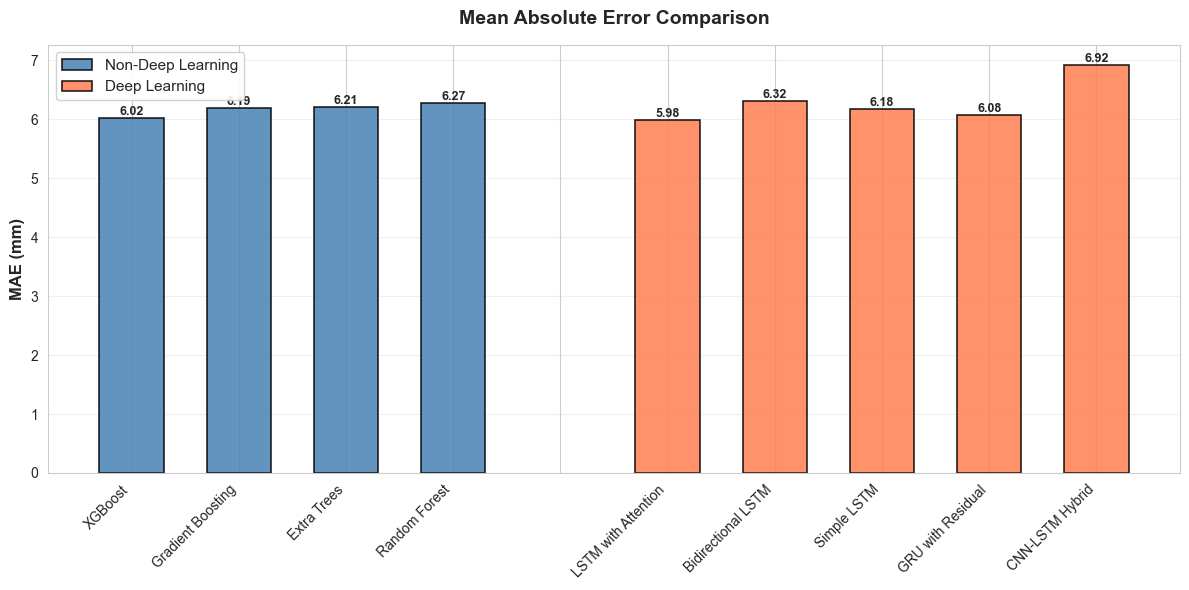

In [33]:
# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Setup positions
x_ndl = np.arange(len(df_ndl_comparison))
x_dl = np.arange(len(df_dl_comparison))
width = 0.6

# Create bars
bars1 = ax.bar(x_ndl, df_ndl_comparison['MAE'], width, 
               color='steelblue', edgecolor='black', linewidth=1.2, 
               label='Non-Deep Learning', alpha=0.85)

bars2 = ax.bar(x_dl + len(x_ndl) + 1, df_dl_comparison['MAE'], width, 
               color='coral', edgecolor='black', linewidth=1.2, 
               label='Deep Learning', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Set x-axis labels
all_labels = list(df_ndl_comparison['Model']) + [''] + list(df_dl_comparison['Model'])
ax.set_xticks(list(x_ndl) + [len(x_ndl)] + list(x_dl + len(x_ndl) + 1))
ax.set_xticklabels(all_labels, rotation=45, ha='right', fontsize=10)

# Formatting
ax.set_ylabel('MAE (mm)', fontsize=12, fontweight='bold')
ax.set_title('Mean Absolute Error Comparison', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


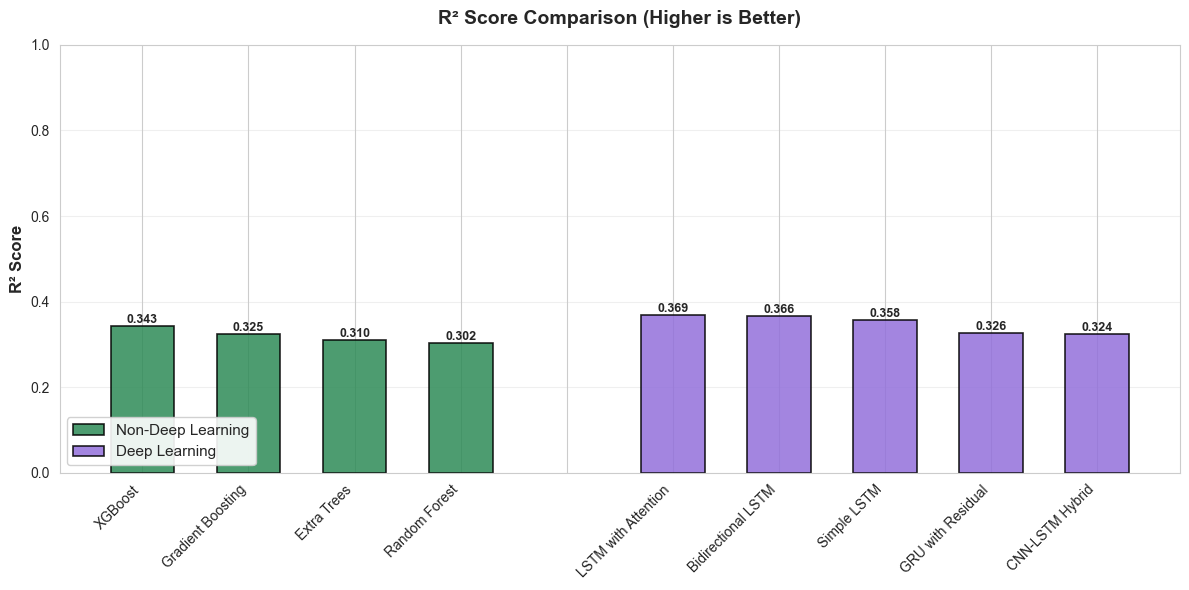

In [36]:
# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Setup positions
x_ndl = np.arange(len(df_ndl_comparison))
x_dl = np.arange(len(df_dl_comparison))
width = 0.6

# Create bars
bars1 = ax.bar(x_ndl, df_ndl_comparison['R²'], width, 
               color='seagreen', edgecolor='black', linewidth=1.2, 
               label='Non-Deep Learning', alpha=0.85)

bars2 = ax.bar(x_dl + len(x_ndl) + 1, df_dl_comparison['R²'], width, 
               color='mediumpurple', edgecolor='black', linewidth=1.2, 
               label='Deep Learning', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')


# Set x-axis labels
all_labels = list(df_ndl_comparison['Model']) + [''] + list(df_dl_comparison['Model'])
ax.set_xticks(list(x_ndl) + [len(x_ndl)] + list(x_dl + len(x_ndl) + 1))
ax.set_xticklabels(all_labels, rotation=45, ha='right', fontsize=10)

# Formatting
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('R² Score Comparison (Higher is Better)', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower left', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()


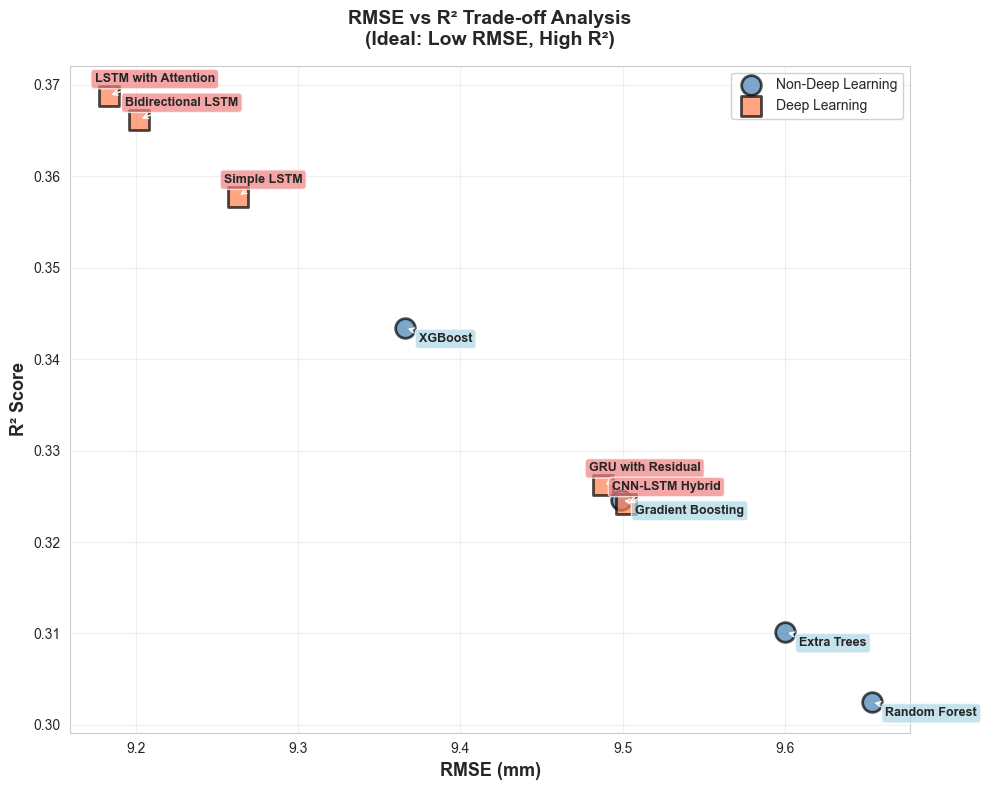

In [37]:
# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Create scatter plots
scatter_ndl = ax.scatter(df_ndl_comparison['RMSE'], df_ndl_comparison['R²'], 
                         s=200, c='steelblue', marker='o', 
                         edgecolors='black', linewidth=2, 
                         label='Non-Deep Learning', alpha=0.7, zorder=3)

scatter_dl = ax.scatter(df_dl_comparison['RMSE'], df_dl_comparison['R²'], 
                        s=200, c='coral', marker='s', 
                        edgecolors='black', linewidth=2, 
                        label='Deep Learning', alpha=0.7, zorder=3)

# Annotate NDL points
for idx, row in df_ndl_comparison.iterrows():
    ax.annotate(row['Model'], 
                (row['RMSE'], row['R²']), 
                xytext=(10, -10),
                textcoords='offset points',
                fontsize=9,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1))

# Annotate DL points
for idx, row in df_dl_comparison.iterrows():
    ax.annotate(row['Model'], 
                (row['RMSE'], row['R²']), 
                xytext=(-10, 10),
                textcoords='offset points',
                fontsize=9,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1))

# Add ideal region shading (low RMSE, high R²)
# ax.axhline(y=0.8, color='green', linestyle='--', linewidth=1.5, alpha=0.4, label='Good R² (>0.8)')
# ax.axvspan(0, df_all_models['RMSE'].min() + 1, alpha=0.1, color='green', label='Low RMSE Region')

# Formatting
ax.set_xlabel('RMSE (mm)', fontsize=13, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=13, fontweight='bold')
ax.set_title('RMSE vs R² Trade-off Analysis\n(Ideal: Low RMSE, High R²)', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='best', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


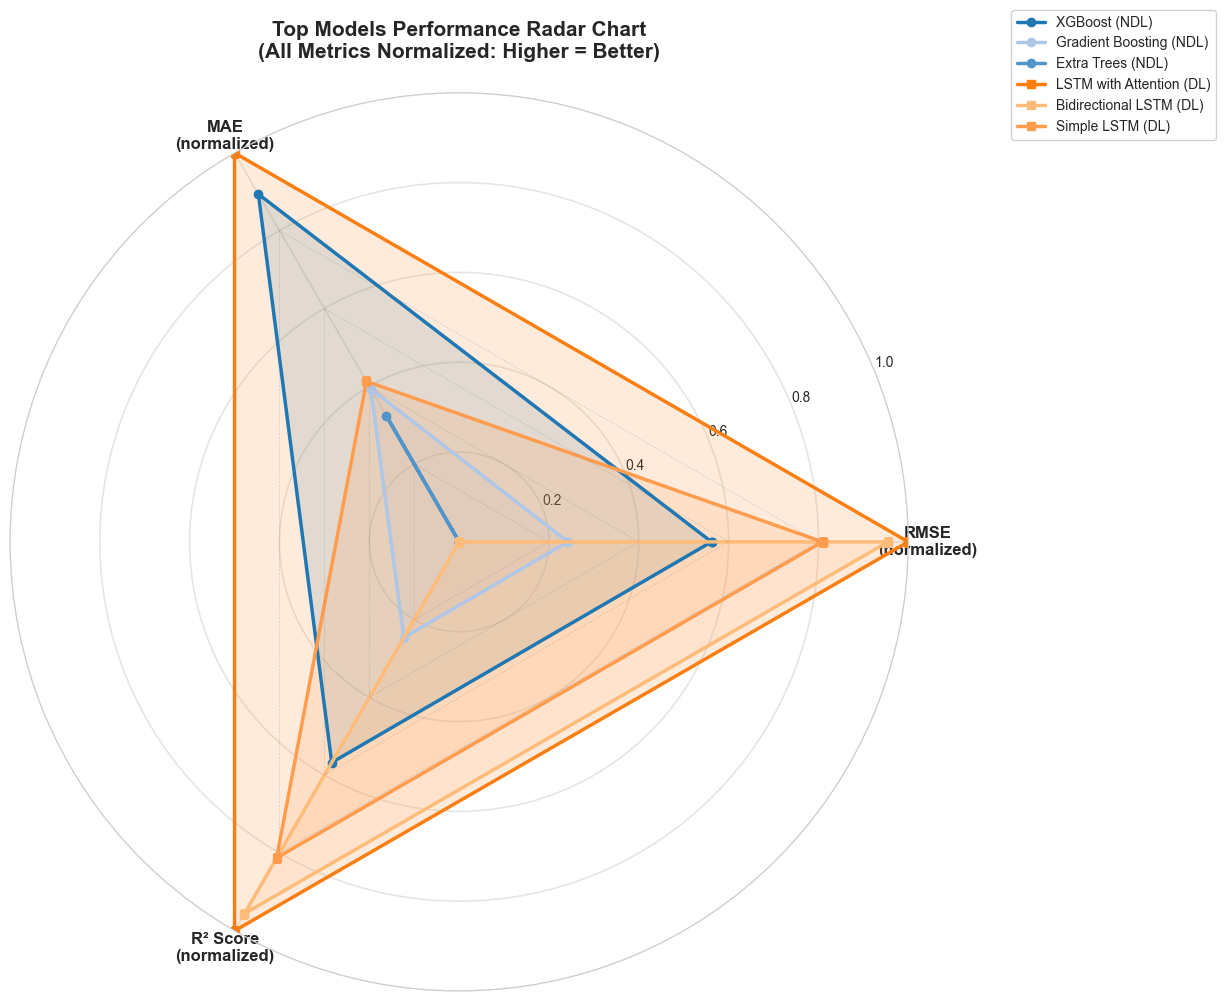

In [40]:
from math import pi

# Create figure
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(projection='polar'))

# Get top 3 from each category
top_ndl = df_ndl_comparison.head(min(3, len(df_ndl_comparison)))
top_dl = df_dl_comparison.head(min(3, len(df_dl_comparison)))

# Combine all top models for global normalization
all_top_models = pd.concat([top_ndl, top_dl], ignore_index=True)

# Normalize metrics GLOBALLY (across all models being plotted)
def normalize_globally(values, all_values, lower_is_better=True):
    """Normalize metrics to 0-1 scale where 1 is always better"""
    if lower_is_better:
        # For RMSE/MAE: lower is better, so invert
        normalized = 1 - (values - all_values.min()) / (all_values.max() - all_values.min() + 1e-10)
    else:
        # For R²: higher is better
        normalized = (values - all_values.min()) / (all_values.max() - all_values.min() + 1e-10)
    return normalized

# Setup categories
categories = ['RMSE\n(normalized)', 'MAE\n(normalized)', 'R² Score\n(normalized)']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Define colors
ndl_colors = ['#1f77b4', '#aec7e8', '#5394c9']  # Blues
dl_colors = ['#ff7f0e', '#ffbb78', '#ff9c4d']   # Oranges/Reds

# Plot top NDL models
for i, (idx, row) in enumerate(top_ndl.iterrows()):
    # Normalize using ALL top models' data
    norm_rmse = normalize_globally(
        row['RMSE'], all_top_models['RMSE'], lower_is_better=True
    )
    norm_mae = normalize_globally(
        row['MAE'], all_top_models['MAE'], lower_is_better=True
    )
    norm_r2 = normalize_globally(
        row['R²'], all_top_models['R²'], lower_is_better=False
    )
    
    values = [norm_rmse, norm_mae, norm_r2]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2.5, 
            label=f"{row['Model']} (NDL)", color=ndl_colors[i])
    ax.fill(angles, values, alpha=0.15, color=ndl_colors[i])

# Plot top DL models
for i, (idx, row) in enumerate(top_dl.iterrows()):
    # Normalize using ALL top models' data
    norm_rmse = normalize_globally(
        row['RMSE'], all_top_models['RMSE'], lower_is_better=True
    )
    norm_mae = normalize_globally(
        row['MAE'], all_top_models['MAE'], lower_is_better=True
    )
    norm_r2 = normalize_globally(
        row['R²'], all_top_models['R²'], lower_is_better=False
    )
    
    values = [norm_rmse, norm_mae, norm_r2]
    values += values[:1]
    
    ax.plot(angles, values, 's-', linewidth=2.5, 
            label=f"{row['Model']} (DL)", color=dl_colors[i])
    ax.fill(angles, values, alpha=0.15, color=dl_colors[i])

# Formatting
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)
ax.set_title('Top Models Performance Radar Chart\n(All Metrics Normalized: Higher = Better)', 
             fontsize=15, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10, framealpha=0.9)
ax.grid(True, linewidth=1.2, alpha=0.5)

# Add background circles for reference
for y in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.plot(angles, [y]*len(angles), '--', linewidth=0.5, color='gray', alpha=0.3)

plt.tight_layout()
plt.show()


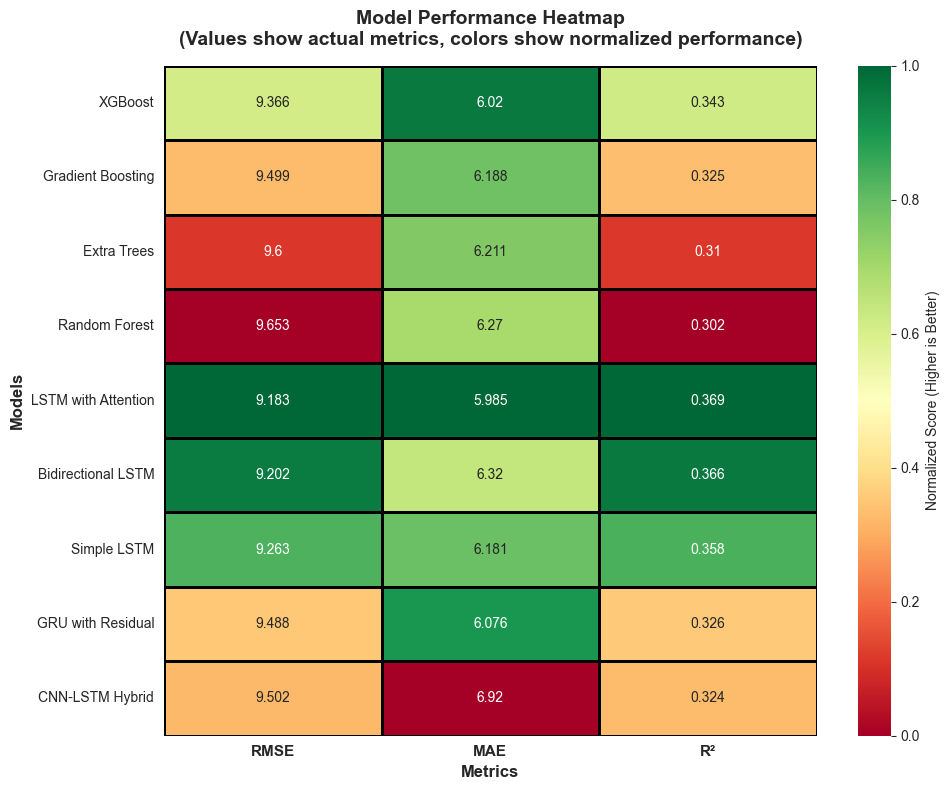

In [39]:
# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Create ranking matrix
ranking_data = []
models_list = list(df_ndl_comparison['Model']) + list(df_dl_comparison['Model'])

for model in models_list:
    if model in df_ndl_comparison['Model'].values:
        row_data = df_ndl_comparison[df_ndl_comparison['Model'] == model].iloc[0]
    else:
        row_data = df_dl_comparison[df_dl_comparison['Model'] == model].iloc[0]
    
    ranking_data.append([row_data['RMSE'], row_data['MAE'], row_data['R²']])

# Create DataFrame
df_heatmap = pd.DataFrame(ranking_data, 
                          columns=['RMSE', 'MAE', 'R²'],
                          index=models_list)

# Normalize for better visualization (0-1 scale)
df_heatmap_norm = df_heatmap.copy()
df_heatmap_norm['RMSE'] = 1 - (df_heatmap['RMSE'] - df_heatmap['RMSE'].min()) / (df_heatmap['RMSE'].max() - df_heatmap['RMSE'].min())
df_heatmap_norm['MAE'] = 1 - (df_heatmap['MAE'] - df_heatmap['MAE'].min()) / (df_heatmap['MAE'].max() - df_heatmap['MAE'].min())
df_heatmap_norm['R²'] = (df_heatmap['R²'] - df_heatmap['R²'].min()) / (df_heatmap['R²'].max() - df_heatmap['R²'].min())

# Create heatmap
sns.heatmap(df_heatmap_norm, annot=df_heatmap.round(3), fmt='', 
            cmap='RdYlGn', center=0.5, linewidths=2, linecolor='black',
            cbar_kws={'label': 'Normalized Score (Higher is Better)'},
            ax=ax, vmin=0, vmax=1)

# Formatting
ax.set_title('Model Performance Heatmap\n(Values show actual metrics, colors show normalized performance)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Models', fontsize=12, fontweight='bold')

# Rotate labels
plt.yticks(rotation=0, fontsize=10)
plt.xticks(rotation=0, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


In [43]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
import openmeteo_requests
import requests_cache
from retry_requests import retry
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print(f"TensorFlow version: {tf.__version__}")
print(f"Current time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Custom Attention Layer (required for loading the model)
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
    
    def build(self, input_shape):
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], input_shape[-1]),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='attention_bias',
            shape=(input_shape[-1],),
            initializer='zeros',
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)
    
    def call(self, x):
        e = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        a = tf.nn.softmax(e, axis=1)
        output = x * a
        return tf.reduce_sum(output, axis=1)
    
    def get_config(self):
        return super(AttentionLayer, self).get_config()

print("✓ Libraries imported and AttentionLayer defined")


TensorFlow version: 2.20.0
Current time: 2026-02-08 13:27:16
✓ Libraries imported and AttentionLayer defined


In [44]:
print("\n" + "="*80)
print("LOADING LSTM WITH ATTENTION MODEL")
print("="*80)

try:
    # Try to load from saved file
    model = load_model('best_lstm_attention.keras', 
                       custom_objects={'AttentionLayer': AttentionLayer})
    print("✓ Model loaded from file: best_lstm_attention.keras")
except Exception as e:
    print(f"⚠ Could not load from file: {e}")
    print("  Attempting to use model from memory...")
    try:
        model = model_attention  # Use the model from training session
        print("✓ Using model from current session")
    except:
        print("✗ Error: Model not found!")
        print("  Please make sure you have either:")
        print("  1. Saved model file 'best_lstm_attention.keras' in current directory")
        print("  2. Trained the model in this session")
        model = None

if model is not None:
    print("\n" + "="*80)
    print("MODEL ARCHITECTURE")
    print("="*80)
    model.summary()
    print("\n✓ Model is ready for predictions!")



LOADING LSTM WITH ATTENTION MODEL
✓ Model loaded from file: best_lstm_attention.keras

MODEL ARCHITECTURE


Model: "LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 24, 128)        │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 64)             │         4,160 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 380,741 (1.45 MB)

 Trainable params: 126,913 (495.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 253,828 (991.52 KB)


✓ Model is ready for predictions!


In [55]:
# Location: Colombo, Sri Lanka
LAT, LON = 6.9355, 79.8487

print("\n" + "="*80)
print("FETCHING WEATHER DATA FOR LAST 24 HOURS")
print("="*80)

# Setup cached session
cache_session = requests_cache.CachedSession('.cache', expire_after=300)  # 5 min cache
retry_session = retry(cache_session, retries=5, backoff_factor=0.25)
openmeteo = openmeteo_requests.Client(session=retry_session)

current_time = datetime.now()
print(f"\nLocation: Colombo ({LAT}°N, {LON}°E)")
print(f"Current time: {current_time.strftime('%Y-%m-%d %H:%M:%S')}")

# Use Forecast API with both past and forecast to get complete recent data
try:
    print("\nFetching from Forecast API...")
    url_forecast = "https://api.open-meteo.com/v1/forecast"
    params_forecast = {
        "latitude": LAT,
        "longitude": LON,
        "hourly": ["temperature_2m", "precipitation"],
        "past_days": 3,  # Get last 3 days to ensure we have enough recent data
        "forecast_days": 1,  # Include today's forecast (if current hour not available in past)
        "timezone": "Asia/Colombo"
    }
    
    responses = openmeteo.weather_api(url_forecast, params_forecast)
    response = responses[0]
    hourly = response.Hourly()
    
    time_index = pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    )
    
    df_all = pd.DataFrame({
        "time_utc": time_index,
        "temperature_2m": hourly.Variables(0).ValuesAsNumpy(),
        "precipitation": hourly.Variables(1).ValuesAsNumpy()
    })
    
    df_all["time"] = df_all["time_utc"].dt.tz_convert("Asia/Colombo")
    df_all = df_all.drop(columns=["time_utc"])
    
    # Keep only past data (exclude future)
    import pytz
    colombo_tz = pytz.timezone('Asia/Colombo')
    current_aware = colombo_tz.localize(current_time)
    
    # Filter: keep data up to current hour (inclusive)
    df_past = df_all[df_all['time'] <= current_aware].copy()
    
    # Sort and get last 24 hours
    df_past = df_past.sort_values("time").reset_index(drop=True)
    df_weather = df_past.tail(24).reset_index(drop=True)
    
    print(f"✓ Successfully fetched {len(df_weather)} hours")
    print(f"  Total data points before filtering: {len(df_all)}")
    print(f"  Past data points (up to now): {len(df_past)}")
    
    if len(df_weather) > 0:
        # Convert to naive for time difference calculation
        latest_time_naive = df_weather['time'].iloc[-1].replace(tzinfo=None)
        oldest_time_naive = df_weather['time'].iloc[0].replace(tzinfo=None)
        time_diff = (current_time - latest_time_naive).total_seconds() / 3600
        
        print(f"\n✓ Final dataset: {len(df_weather)} hours")
        print(f"  Oldest: {df_weather['time'].iloc[0].strftime('%Y-%m-%d %H:%M')} ({(current_time - oldest_time_naive).total_seconds()/3600:.1f}h ago)")
        print(f"  Latest: {df_weather['time'].iloc[-1].strftime('%Y-%m-%d %H:%M')} ({time_diff:.1f}h ago)")
        
        if time_diff > 2:
            print(f"\nWARNING: Latest data is {time_diff:.1f} hours old!")
            print(f"   This is older than expected. Prediction may be less accurate.")
        else:
            print(f"\n✓ Data freshness: Good (only {time_diff:.1f}h old)")
    else:
        print("✗ No data retrieved")
        df_weather = None
    
except Exception as e:
    print(f"✗ Error: {e}")
    import traceback
    traceback.print_exc()
    df_weather = None



FETCHING WEATHER DATA FOR LAST 24 HOURS

Location: Colombo (6.9355°N, 79.8487°E)
Current time: 2026-02-08 13:42:26

Fetching from Forecast API...
✓ Successfully fetched 24 hours
  Total data points before filtering: 96
  Past data points (up to now): 86

✓ Final dataset: 24 hours
  Oldest: 2026-02-07 14:00 (23.7h ago)
  Latest: 2026-02-08 13:00 (0.7h ago)

✓ Data freshness: Good (only 0.7h old)


In [56]:
if df_weather is not None:
    print("\n" + "="*80)
    print("WEATHER DATA - LAST 24 HOURS")
    print("="*80)
    
    # Show first 5 and last 5 hours
    print("\nFirst 5 hours (oldest):")
    print(df_weather.head().to_string(index=False))
    
    print("\nLast 5 hours (most recent):")
    print(df_weather.tail().to_string(index=False))
    
    # Summary statistics
    print("\n" + "="*80)
    print("SUMMARY STATISTICS")
    print("="*80)
    print(f"Temperature:")
    print(f"  Average:    {df_weather['temperature_2m'].mean():.1f}°C")
    print(f"  Min:        {df_weather['temperature_2m'].min():.1f}°C")
    print(f"  Max:        {df_weather['temperature_2m'].max():.1f}°C")
    print(f"\nPrecipitation:")
    print(f"  Total:      {df_weather['precipitation'].sum():.2f} mm")
    print(f"  Max (1h):   {df_weather['precipitation'].max():.2f} mm")
    print(f"  Hours with rain: {(df_weather['precipitation'] > 0).sum()} / 24 hours")



WEATHER DATA - LAST 24 HOURS

First 5 hours (oldest):
 temperature_2m  precipitation                      time
      27.403500            0.0 2026-02-07 14:00:00+05:30
      27.103500            0.0 2026-02-07 15:00:00+05:30
      27.103500            0.0 2026-02-07 16:00:00+05:30
      28.053499            0.0 2026-02-07 17:00:00+05:30
      28.003500            0.0 2026-02-07 18:00:00+05:30

Last 5 hours (most recent):
 temperature_2m  precipitation                      time
      26.203501            0.0 2026-02-08 09:00:00+05:30
      26.953501            0.0 2026-02-08 10:00:00+05:30
      27.853500            0.0 2026-02-08 11:00:00+05:30
      28.703501            0.0 2026-02-08 12:00:00+05:30
      29.103500            0.0 2026-02-08 13:00:00+05:30

SUMMARY STATISTICS
Temperature:
  Average:    27.0°C
  Min:        25.6°C
  Max:        29.1°C

Precipitation:
  Total:      0.00 mm
  Max (1h):   0.00 mm
  Hours with rain: 0 / 24 hours


In [57]:
len(df_weather)

24

In [58]:
if df_weather is not None and model is not None:
    # Prepare and predict
    X_input = df_weather[['temperature_2m', 'precipitation']].values.reshape(1, 24, 2)
    predicted_rainfall = float(model.predict(X_input, verbose=0)[0][0])
    
    print(f"Predicted rainfall: {predicted_rainfall:.2f} mm")


Predicted rainfall: 2.04 mm


In [59]:
if df_weather is not None and model is not None:
    print("\n" + "="*80)
    print("COMPARING PREDICTIONS: YOUR MODEL vs OPEN-METEO")
    print("="*80)
    
    # 1. YOUR MODEL'S PREDICTION
    print("\n[1/2] Getting prediction from YOUR LSTM model...")
    X_input = df_weather[['temperature_2m', 'precipitation']].values.reshape(1, 24, 2)
    your_prediction = float(model.predict(X_input, verbose=0)[0][0])
    
    latest_time = df_weather['time'].iloc[-1]
    prediction_start = latest_time
    prediction_end = latest_time + timedelta(hours=24)
    
    print(f"✓ Your model predicts: {your_prediction:.2f} mm")
    print(f"  For period: {prediction_start.strftime('%Y-%m-%d %H:%M')} → {prediction_end.strftime('%Y-%m-%d %H:%M')}")
    
    # 2. OPEN-METEO'S FORECAST
    print("\n[2/2] Getting forecast from Open-Meteo API...")
    
    try:
        # Setup API client
        cache_session = requests_cache.CachedSession('.cache', expire_after=300)
        retry_session = retry(cache_session, retries=5, backoff_factor=0.25)
        openmeteo = openmeteo_requests.Client(session=retry_session)
        
        # Fetch forecast
        url_forecast = "https://api.open-meteo.com/v1/forecast"
        params_forecast = {
            "latitude": LAT,
            "longitude": LON,
            "hourly": ["temperature_2m", "precipitation"],
            "forecast_days": 2,  # Get 2 days of forecast to ensure we have next 24h
            "timezone": "Asia/Colombo"
        }
        
        responses = openmeteo.weather_api(url_forecast, params_forecast)
        response = responses[0]
        hourly = response.Hourly()
        
        # Process forecast data
        time_index = pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left"
        )
        
        df_forecast = pd.DataFrame({
            "time_utc": time_index,
            "temperature_2m": hourly.Variables(0).ValuesAsNumpy(),
            "precipitation": hourly.Variables(1).ValuesAsNumpy()
        })
        
        df_forecast["time"] = df_forecast["time_utc"].dt.tz_convert("Asia/Colombo")
        df_forecast = df_forecast.drop(columns=["time_utc"])
        
        # Get FUTURE data (next 24 hours from the latest time in your input)
        import pytz
        colombo_tz = pytz.timezone('Asia/Colombo')
        current_aware = colombo_tz.localize(datetime.now())
        
        # Filter: Get data from current hour onwards (future only)
        df_future = df_forecast[df_forecast['time'] > latest_time].copy()
        
        # Get exactly the next 24 hours
        df_next_24h = df_future.head(24).reset_index(drop=True)
        
        if len(df_next_24h) >= 24:
            # Calculate Open-Meteo's predicted total rainfall
            openmeteo_prediction = df_next_24h['precipitation'].sum()
            
            print(f"✓ Open-Meteo predicts: {openmeteo_prediction:.2f} mm")
            print(f"  For period: {df_next_24h['time'].iloc[0].strftime('%Y-%m-%d %H:%M')} → {df_next_24h['time'].iloc[-1].strftime('%Y-%m-%d %H:%M')}")
            print(f"  ({len(df_next_24h)} hours of forecast data)")
            
            # COMPARISON
            print("\n" + "="*80)
            print("COMPARISON RESULTS")
            print("="*80)
            
            difference = your_prediction - openmeteo_prediction
            diff_percentage = (difference / max(openmeteo_prediction, 0.01)) * 100
            
            print(f"\nYour Model (LSTM):      {your_prediction:.2f} mm")
            print(f"Open-Meteo Forecast:    {openmeteo_prediction:.2f} mm")
            print(f"Difference:             {difference:+.2f} mm ({diff_percentage:+.1f}%)")
            
            if abs(difference) < 2:
                print(f"\n✓ Close agreement! (difference < 2mm)")
            elif abs(difference) < 5:
                print(f"\n→ Moderate difference (2-5mm)")
            else:
                print(f"\n⚠️  Significant difference (>5mm)")
            
            # Determine which predicts more rain
            if your_prediction > openmeteo_prediction:
                print(f"   Your model predicts MORE rain than Open-Meteo")
            elif your_prediction < openmeteo_prediction:
                print(f"   Your model predicts LESS rain than Open-Meteo")
            else:
                print(f"   Both predictions are identical!")
            
            print("="*80)
            
            # Store comparison data for visualization
            comparison_data = {
                'your_model': your_prediction,
                'openmeteo': openmeteo_prediction,
                'difference': difference,
                'diff_percentage': diff_percentage,
                'forecast_period_start': df_next_24h['time'].iloc[0],
                'forecast_period_end': df_next_24h['time'].iloc[-1],
                'hourly_openmeteo': df_next_24h
            }
            
        else:
            print(f"✗ Only {len(df_next_24h)} hours of forecast available (need 24)")
            print("  Cannot compare predictions accurately.")
            comparison_data = None
            openmeteo_prediction = None
            
    except Exception as e:
        print(f"✗ Error fetching Open-Meteo forecast: {e}")
        import traceback
        traceback.print_exc()
        comparison_data = None
        openmeteo_prediction = None



COMPARING PREDICTIONS: YOUR MODEL vs OPEN-METEO

[1/2] Getting prediction from YOUR LSTM model...
✓ Your model predicts: 2.04 mm
  For period: 2026-02-08 13:00 → 2026-02-09 13:00

[2/2] Getting forecast from Open-Meteo API...
✓ Open-Meteo predicts: 0.00 mm
  For period: 2026-02-08 14:00 → 2026-02-09 13:00
  (24 hours of forecast data)

COMPARISON RESULTS

Your Model (LSTM):      2.04 mm
Open-Meteo Forecast:    0.00 mm
Difference:             +2.04 mm (+20391.3%)

→ Moderate difference (2-5mm)
   Your model predicts MORE rain than Open-Meteo
